# 🏠 Stage 6 — Correlation & Regression Statistics
## Real Estate Price Prediction — From Correlation to OLS to Logistic Regression

---

> 📌 **Tamil:** "Correlation = இரண்டு variables எந்தளவு relate ஆகின்றன.  
> Regression = ஒன்றை வைத்து மற்றொன்றை predict பண்ணும் model. ஒரு அல்லது பல features-ஐ வைத்து ஒரு value-ஐ predict செய்வது.
> Statistics-இலிருந்து ML-க்கு bridge இந்த stage."

---

நீ ஒரு வீட்டின் விலையை (House Price) கணிக்க வேண்டும் என்று நினை.

வீட்டின்:

Size (எவ்வளவு பெரியது?)
Bedrooms (எத்தனை அறைகள்?)
Age (எவ்வளவு பழைய வீடு?)
Location (எந்த இடம்?)

இவைகளை பார்த்து வீட்டின் விலையை கணிக்கலாம்.

இதைத்தான் Regression என்று சொல்வோம்

---
correlation
| Value | Meaning           | 
| ----- | ----------------- |
| +1    | Perfect Positive  |
| +0.8  | Strong Positive   |
| +0.5  | Moderate Positive |
| 0     | No Relation       |
| -0.5  | Moderate Negative |
| -1    | Perfect Negative  |

---

### 4 Projects in this Notebook

| # | Project | Dataset | Method | Business Question |
|---|---------|---------|--------|-------------------|
| 1 | Real estate prices | `house_prices.csv` | OLS Multiple Regression | Which features drive house price? ("வீட்டு விலையை அதிகமாக பாதிப்பது எது?") |
| 2 | Correlation deep-dive | `house_prices.csv` | Pearson + Spearman + VIF | Which variables are truly related? |
| 3 | Residual diagnostics | `house_prices.csv` | Residual analysis | Is our model valid? |
| 4 | Loan default prediction | `loan_data.csv` | Logistic Regression | Will this customer default? |

---

---

| # | தலைப்பு                     | Full Form                                          | வரையறை (Define)                                                                     | உதாரணம்                                                | Rule / எப்படி படிப்பது?                                               |
| - | --------------------------- | -------------------------------------------------- | ----------------------------------------------------------------------------------- | ------------------------------------------------------ | --------------------------------------------------------------------- |
| 1 | **OLS Multiple Regression** | **Ordinary Least Squares**                         | பல Features-ஐ பயன்படுத்தி ஒரு Continuous Value-ஐ (எ.கா. House Price) கணிக்கும் முறை(ஒரு விஷயத்தின் மதிப்பை (Price, Salary போன்றவை) பல காரணிகளை வைத்து கணிப்பது.) | வீட்டு Size, Bedrooms, Age வைத்து House Price கணித்தல் | p-value < 0.05 என்றால் அந்த Feature முக்கியமானது , > 0.05 - முக்கியமல்ல                     |
| 2 | **Pearson Correlation**     | **Pearson Product-Moment Correlation Coefficient** | இரண்டு Variables நேர்கோட்டில் (Linear) தொடர்புடையதா என்பதை அளக்கும் அளவீடு          | Study Hours ↔ Marks                                    | r = +1 (முழு Positive), r = -1 (முழு Negative), r = 0 (தொடர்பு இல்லை) |
| 3 | **Spearman Correlation**    | **Spearman Rank Correlation Coefficient**          | Rank அல்லது Order அடிப்படையில் தொடர்பு உள்ளதா என்பதை பார்க்கும் (Data Normal இல்லாத போது, Outliers அதிகம் இருக்கும் போது)                   | Class Rank ↔ Exam Rank                                 | -1 (முழு Negative) +1 (முழு Positive) ,0 (தொடர்பு இல்லை)                                            |
| 4 | **VIF**                     | **Variance Inflation Factor**                      | Features ஒன்றுக்கொன்று அதிகமாக தொடர்புடையதா (Multicollinearity) என்பதை கண்டறியும் (ஒரே மாதிரி தகவலை இரண்டு Columns கொடுக்கிறதா என்பதை பார்க்கும்.)  | House Size & Living Area (இரண்டும் கிட்டத்தட்ட ஒரே தகவல்.)                              | VIF < 5 நல்லது, 5 - 10 கவனம் தேவை, VIF > 10 Multicollinearity பிரச்சினை                                   |
| 5 | **Residual Analysis**       | Residual = Actual − Predicted                      | Model செய்த தவறுகளை (Errors) ஆய்வு செய்வது                                          | Actual Price = ₹50L, Predicted = ₹48L                  | Residuals Random ஆக இருந்தால் Model நல்லது, Pattern தெரிகிறது - Model சரியில்லை , மிக பெரிய Errors - Prediction மோசம்                           |
| 6 | **Logistic Regression**     | Logistic Regression                                | Yes/No, Pass/Fail போன்ற முடிவுகளை Predict செய்யும் முறை                             | Loan Default ஆகுமா?                                    | Probability > 0.5 → Yes, < 0.5 → No                                   |


## ⚙️ Step 0 — Imports & Setup

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PURPLE='#534AB7'; TEAL='#0F6E56'; AMBER='#BA7517'
CORAL='#993C1D'; BLUE='#185FA5'; DGRAY='#5F5E5A'; GREEN='#3B6D11'
COLORS = [PURPLE, TEAL, AMBER, CORAL, BLUE, GREEN, DGRAY]

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FFFFFF',
    'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
})
print("All libraries ready!")
print("  statsmodels — OLS, summary tables, VIF, Durbin-Watson")
print("  scipy       — Pearson, Spearman correlation")
print("  sklearn     — LogisticRegression, ROC-AUC, confusion matrix")


All libraries ready!
  statsmodels — OLS, summary tables, VIF, Durbin-Watson
  scipy       — Pearson, Spearman correlation
  sklearn     — LogisticRegression, ROC-AUC, confusion matrix


---
## 🗄️ Dataset Generation — Realistic Indian Real Estate Data

We generate **1,500 properties** with realistic correlations between features and price.

> 📌 **Tamil:** "Chennai, Mumbai, Delhi, Bangalore properties — realistic price relationships  
> area, bedrooms, quality, age → price. Synthetic ஆனால் statistically realistic."


In [ ]:
np.random.seed(42)
n = 1500

# ── Base features ─────────────────────────────────────────────
area_sqft  = np.random.normal(1800, 600, n).clip(500, 5000).round(0)
bedrooms   = np.random.choice([1,2,3,4,5], n, p=[0.05,0.20,0.45,0.22,0.08])
bathrooms  = (bedrooms * np.random.uniform(0.5, 0.9, n)).round(0).clip(1, 4)
year_built = np.random.randint(1985, 2024, n)
age        = 2024 - year_built
quality    = np.random.choice(range(1,11), n,
                               p=[0.02,0.05,0.08,0.12,0.15,0.18,0.18,0.12,0.07,0.03])
location_score = np.random.uniform(1, 10, n).round(1)
floor_num  = np.random.randint(0, 25, n)
has_parking= np.random.binomial(1, 0.65, n)
has_gym    = np.random.binomial(1, 0.30, n)
city       = np.random.choice(['Mumbai','Delhi','Bangalore','Chennai','Hyderabad'],
                               n, p=[0.25,0.22,0.20,0.18,0.15])

# City multiplier (Mumbai most expensive)
city_mult  = {'Mumbai':1.8,'Delhi':1.4,'Bangalore':1.3,'Chennai':1.0,'Hyderabad':1.1}
c_mult     = np.array([city_mult[c] for c in city])

# ── Price formula (realistic relationships) ────────────────────
noise = np.random.normal(0, 0.08, n)
log_price = (
    10.5                             # base (in log ₹)
    + 0.0004  * area_sqft           # bigger = more expensive
    + 0.08    * quality             # quality premium
    + 0.05    * location_score      # location premium
    - 0.012   * age                 # older = cheaper
    + 0.10    * has_parking         # parking premium
    + 0.06    * has_gym             # gym premium
    + 0.12    * np.log(c_mult)      # city multiplier
    + noise
)
price_lakhs = np.exp(log_price) / 1e5   # convert to ₹ lakhs

# ── Add deliberate multicollinearity ──────────────────────────
total_rooms = bedrooms + bathrooms      # highly correlated with bedrooms

df_house = pd.DataFrame({
    'property_id'   : [f'P{i:04d}' for i in range(1, n+1)],
    'city'          : city,
    'area_sqft'     : area_sqft.astype(int),
    'bedrooms'      : bedrooms,
    'bathrooms'     : bathrooms.astype(int),
    'total_rooms'   : total_rooms.astype(int),
    'year_built'    : year_built,
    'age_years'     : age,
    'overall_quality': quality,
    'location_score': location_score,
    'floor'         : floor_num,
    'has_parking'   : has_parking,
    'has_gym'       : has_gym,
    'price_lakhs'   : price_lakhs.round(2),
})

df_house.to_csv('house_prices.csv', index=False)
print(f"Dataset saved: house_prices.csv")
print(f"  {len(df_house):,} properties x {df_house.shape[1]} columns")
print(f"  Price range: ₹{df_house['price_lakhs'].min():.1f}L — ₹{df_house['price_lakhs'].max():.1f}L")
print(f"  Median price: ₹{df_house['price_lakhs'].median():.1f}L")
df_house.head(8)

# overall quality : 
# | Quality | Meaning |
# | ------- | ------- |
# | 2       | Poor    |
# | 5       | Average |
# | 10      | Luxury  |
# location score :
# | Location    | Score |
# | ----------- | ----- |
# | Village     | 2     |
# | City Center | 9     |
# has parking : 0 = No parking, 1 = Has parking
# has gym : 0 = No gym, 1 = Has gym


Dataset saved: house_prices.csv
  1,500 properties x 14 columns
  Price range: ₹0.5L — ₹5.2L
  Median price: ₹1.4L


,property_id,city,area_sqft,bedrooms,bathrooms,total_rooms,year_built,age_years,overall_quality,location_score,floor,has_parking,has_gym,price_lakhs
0,P0001,Hyderabad,2098,3,2,5,2003,21,6,2.8,8,1,0,1.49
1,P0002,Hyderabad,1717,4,3,7,2001,23,7,3.9,4,1,0,1.44
2,P0003,Chennai,2189,3,3,6,2017,7,9,6.3,1,0,1,2.33
3,P0004,Mumbai,2714,2,2,4,1996,28,6,1.7,1,0,1,1.51
4,P0005,Chennai,1660,2,1,3,1987,37,6,2.3,6,1,0,0.82
5,P0006,Mumbai,1660,3,2,5,2010,14,2,1.7,16,1,0,0.88
6,P0007,Hyderabad,2748,4,2,6,2019,5,2,8.3,9,1,1,2.11
7,P0008,Mumbai,2260,4,4,8,1992,32,4,7.8,11,1,0,1.40


---
---
# 🔗 Project 1 — Correlation Analysis
## Pearson + Spearman + VIF Multicollinearity

---

### What is Correlation?

> 📌 **Tamil:** "Correlation coefficient r = -1 to +1.  
> r = +1 → perfect positive (area increases → price increases).  
> r = -1 → perfect negative (age increases → price decreases).  
> r = 0  → no linear relationship."

| r value | Strength |
|---------|---------|
| 0.9 – 1.0 | Very strong |
| 0.7 – 0.9 | Strong |
| 0.5 – 0.7 | Moderate |
| 0.3 – 0.5 | Weak |
| 0.0 – 0.3 | Very weak / no correlation |

---

| VIF    | Meaning                | தமிழ் விளக்கம்    |
| ------ | ---------------------- | ----------------- |
| < 5    | Good                   | பிரச்சினை இல்லை   |
| 5 – 10 | Warning                | கவனம் தேவை        |
| > 10   | High Multicollinearity | Feature நீக்கலாம் |


### Pearson vs Spearman
- **Pearson** — measures linear relationship, assumes normality - இரண்டு Variables-க்கு இடையேயான Linear Relationship (நேர்கோட்டு தொடர்பு) அளவிடுகிறது. when to use: continuous Data, normal distribution, linear relationship

- **Spearman** — measures rank-based (monotonic) relationship, robust to outliers & non-normality - Values-ஐ நேரடியாக பார்க்காமல் அவற்றின் Rank (தரவரிசை) அடிப்படையில் தொடர்பை அளவிடும். ✅ Rank Data, ✅ Outliers அதிகம், ✅ Normal Distribution இல்லை, ✅ Monotonic Relationship(எப்போதும் ஒரே திசையில் (↑ அல்லது ↓) நகரும் தொடர்பு, ஆனால் நேர்கோடு இருக்க வேண்டிய அவசியம் இல்லை.)

---

| Feature       | Pearson r   | Meaning              |
| ------------- | ----------- | -------------------- |
| +ve           | Positive    | Feature ↑ → Price ↑  |
| -ve           | Negative    | Feature ↑ → Price ↓  |
| 0க்கு அருகில் | No Relation | தொடர்பு மிகக் குறைவு |

--- 

| Condition       | Use      |
| --------------- | -------- |
| Linear + Normal | Pearson  |
| Non-Normal      | Spearman |
| Many Outliers   | Spearman |
| Rank Data       | Spearman |



In [ ]:
numeric_cols = ['area_sqft','bedrooms','bathrooms','total_rooms',
                'age_years','overall_quality','location_score',
                'floor','has_parking','has_gym','price_lakhs']

# ── Pearson Correlation Matrix ─────────────────────────────────
pearson_corr  = df_house[numeric_cols].corr(method='pearson')
spearman_corr = df_house[numeric_cols].corr(method='spearman')

# "House Price (price_lakhs) உடன் எந்த Features அதிக தொடர்பு கொண்டுள்ளன?"
print("── Pearson Correlation with PRICE (sorted) ──")
price_pearson  = pearson_corr['price_lakhs'].drop('price_lakhs').sort_values(key=abs, ascending=False)
price_spearman = spearman_corr['price_lakhs'].drop('price_lakhs').sort_values(key=abs, ascending=False)

print(f"{'Feature':<20} {'Pearson r':>12} {'Spearman r':>12} {'Strength'}")
print("-"*60)
for feat in price_pearson.index:
    pr = price_pearson[feat]
    sr = price_spearman[feat]
    strength = ('Very strong' if abs(pr)>0.7 else
                'Strong'      if abs(pr)>0.5 else
                'Moderate'    if abs(pr)>0.3 else 'Weak')
    print(f"  {feat:<18} {pr:>12.4f} {sr:>12.4f}   {strength}")

# ஆம், இந்த code-ல் Strength (Strong, Moderate, Weak) என்பது Pearson r value அடிப்படையில் மட்டுமே கணக்கிடப்பட்டுள்ளது.
# | Metric   | Value  | Area sqft
# | -------- | ------ |
# | Pearson  | 0.6386 |
# | Spearman | 0.6356 | Area அதிகரித்தால் Price அதிகரிக்கிறது. Strong Positive Correlation

# | Metric   | Value   | Age (years)
# | -------- | ------- |
# | Pearson  | -0.3745 |
# | Spearman | -0.3858 | வீடு பழையதாக ஆக ஆக விலை குறைகிறது. Moderate Negative Correlation

# | Metric  | Value  | has gym
# | ------- | ------ |
# | Pearson | 0.0601 |Gym இருப்பதால் விலை கொஞ்சம் கூடலாம். ஆனால் தாக்கம் மிகவும் குறைவு. Weak Correlation


# important :  Scatter Plot
# Area vs Price
# நேர்கோடு போல இருந்தால்: ✅ Pearson
# வளைவு (Curve) போல இருந்தால்: ✅ Spearman
# Data
#  ↓
# EDA
#  ↓
# Pearson / Spearman தேர்வு
#  ↓
# Correlation Analysis

── Pearson Correlation with PRICE (sorted) ──
Feature                 Pearson r   Spearman r Strength
------------------------------------------------------------
  area_sqft                0.6386       0.6356   Strong
  overall_quality          0.4470       0.4513   Moderate
  age_years               -0.3745      -0.3858   Moderate
  location_score           0.3480       0.3439   Moderate
  has_parking              0.1249       0.1229   Weak
  has_gym                  0.0601       0.0628   Weak
  floor                    0.0207       0.0225   Weak
  bedrooms                 0.0098       0.0053   Weak
  total_rooms              0.0063       0.0117   Weak
  bathrooms                0.0015       0.0168   Weak


In [ ]:
# ── Correlation significance testing ──────"Correlation இருக்கிறது. ஆனால் அது உண்மையிலேயே முக்கியமானதா (Significant) அல்லது சும்மா Random-ஆ வந்ததா?" என்பதை கண்டுபிடிப்பது

# | Column  | Meaning                 |
# | ------- | ----------------------- |
# | r       | Correlation Coefficient | Area அதிகரித்தால் Price அதிகரிக்கும்.
# | t-stat  | Test Statistic          | Correlation எவ்வளவு வலிமையானது என்பதை Test செய்யும் மதிப்பு.
# | p-value | Significance Value      | H₀ (Null Hypothesis) Correlation இல்லை H₁ (Alternative Hypothesis) Correlation உள்ளது
# | Sig?    | Significant ஆ?         |

# | t-value       (rule)                       |
# | ------------------------------------ |
# | பெரியதாக இருந்தால் → Strong Evidence |
# | சிறியதாக இருந்தால் → Weak Evidence   |

# | p-value | Decision                 |
# | ------- | ------------------------ |
# | < 0.05  | H₀ Reject                |
# | > 0.05  | H₀ Reject செய்ய முடியாது |

print("── Correlation Significance Tests (vs Price) ──")
print(f"{'Feature':<20} {'r':>8} {'t-stat':>9} {'p-value':>10} {'Sig?':>7}")
print("-"*58)
for feat in price_pearson.index:
    r   = price_pearson[feat]
    n_  = len(df_house)
    t   = r * np.sqrt((n_-2)/(1-r**2))
    p   = 2*(1 - stats.t.cdf(abs(t), df=n_-2))
    print(f"  {feat:<18} {r:>8.4f} {t:>9.3f} {p:>10.4f}   {'Yes' if p<0.05 else 'No'}")

# | Metric  | Value  |
# | ------- | ------ |
# | r       | 0.6386 |
# | p-value | 0.0000 | வீட்டு பரப்பளவு அதிகரித்தால் விலையும் அதிகரிக்கிறது. ✅ Strong Correlation ✅ Significant

# | Metric  | Value   |
# | ------- | ------- |
# | r       | -0.3745 |
# | p-value | 0.0000  | வீடு பழையதாக ஆக ஆக விலை குறைகிறது. ✅ Moderate Negative Correlation ✅ Significant

# | r      | p-value |
# | ------ | ------- |
# | 0.0207 | 0.4241  | Floor மற்றும் Price இடையே தொடர்பு இருப்பதற்கான ஆதாரம் இல்லை. Not Significant

# important : 
# Correlation (r) தொகையை (Amount) சொல்லாது. Area = 0.6386 நீங்கள் இதை இப்படிப் படிக்கக்கூடாது:
# Area 1 sqft அதிகரித்தால்
# Price ₹0.6386 லட்சம் அதிகரிக்கும்
# ❌ தவறு
# சரியான அர்த்தம் r = 0.6386 என்றால்:
# Area மற்றும் Price இடையே வலுவான Positive Relationship உள்ளது.
# அதாவது
# Area ↑
# Price ↑ என்பதை மட்டும் சொல்கிறது.
# Correlation சொல்லாதது : எவ்வளவு ரூபாய் அதிகரிக்கும்? என்று சொல்லாது.

── Correlation Significance Tests (vs Price) ──
Feature                     r    t-stat    p-value    Sig?
----------------------------------------------------------
  area_sqft            0.6386    32.117     0.0000   Yes
  overall_quality      0.4470    19.341     0.0000   Yes
  age_years           -0.3745   -15.632     0.0000   Yes
  location_score       0.3480    14.367     0.0000   Yes
  has_parking          0.1249     4.873     0.0000   Yes
  has_gym              0.0601     2.332     0.0198   Yes
  floor                0.0207     0.800     0.4241   No
  bedrooms             0.0098     0.380     0.7041   No
  total_rooms          0.0063     0.245     0.8063   No
  bathrooms            0.0015     0.058     0.9539   No


In [ ]:
# ── VIF — Multicollinearity Detection ───────────────────────── பணவீக்கம்
# ❌ VIF = பணவீக்கம் (Inflation) அல்ல இங்கே "Inflation" என்பது பொருளாதார பணவீக்கம் அல்ல.
# ✅ VIFஅதாவது: "ஒரு Feature-ன் தகவலை மற்ற Features எவ்வளவு Duplicate ஆக சொல்லுகின்றன?" என்பதை அளவிடும் அளவீடு.
# | VIF   | Meaning         
# | ----- | --------------- |
# | 1     | தொடர்பு இல்லை   
# | 1 - 5 | நல்லது         
# | > 5   | கவனம் தேவை      
# | > 10  | பெரிய(Multicollinearity) பிரச்சினை 

# | Bedrooms | Bathrooms | Total Rooms |
# | -------- | --------- | ----------- |
# | 2        | 1         | 3           |
# | 3        | 2         | 5           |
# | 4        | 3         | 7           |இங்கே Total Rooms-ஐ பார்த்தாலே Bedrooms, Bathrooms பற்றி தெரியும்.
# பிரச்சினை என்ன? Regression குழப்பமடையும். Price உயர காரணம் Bedrooms ஆ? அல்லது Total Rooms ஆ? என்று தெரியாது.

# VIF (Variance Inflation Factor) என்பது Features ஒன்றுக்கொன்று அதிக தொடர்பு (Multicollinearity) உள்ளதா என்பதை கண்டுபிடிக்கும் அளவீடு. 
# VIF > 5 என்றால் கவனம் தேவை, VIF > 10 என்றால் பெரிய Multicollinearity பிரச்சினை. அத்தகைய Features-ஐ Regression Model-லிருந்து நீக்குவது நல்லது.

print("── Variance Inflation(பணவீக்கம்) Factor (VIF) ──")
print("VIF > 5 = multicollinearity concern")
print("VIF > 10 = severe multicollinearity — drop the feature")
print()

vif_features = ['area_sqft','bedrooms','bathrooms','total_rooms',
                'age_years','overall_quality','location_score','floor']
X_vif = df_house[vif_features].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': vif_features,
    'VIF'    : [variance_inflation_factor(X_vif.values, i+1)  # ஒவ்வொரு Feature-க்கும் VIF மதிப்பை கணக்கிடுகிறது.
                for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))
print()
high_vif = vif_data[vif_data['VIF'] > 5]['Feature'].tolist()
print(f"  High VIF features (>5): {high_vif}")
print(f"  => DROP these from regression to avoid multicollinearity")
print(f"  => 'total_rooms' is just bedrooms+bathrooms — expected VIF!")

# முதலில் VIF என்றால் என்ன? ஒரு Feature-ன் தகவலை மற்ற Features ஏற்கனவே சொல்லுகிறதா என்பதை பார்க்கும் அளவீடு.
# inf என்றால் என்ன? inf = Infinity (முடிவில்லாதது) அதாவது 100% Multicollinearity

# Total Rooms = Bedrooms + Bathrooms என்பது Regression-க்கு முழுமையாக தெரிகிறது.
# அதனால் Bedrooms, Bathrooms,Total Rooms மூன்றும் ஒரே தகவலை தருகின்றன. அதனால் VIF = inf
# Regression சொல்கிறது: Total Rooms தெரியும் ,அப்படியானால் Bedrooms ஏன் வேண்டும்? Bathrooms ஏன் வேண்டும்?

# area_sqft, VIF = 1.006
# Meaning : Area மற்ற Features-உடன் தொடர்பு இல்லை. ✅ நல்ல Feature

── Variance Inflation Factor (VIF) ──
VIF > 5 = multicollinearity concern
VIF > 10 = severe multicollinearity — drop the feature

        Feature      VIF
       bedrooms      inf
      bathrooms      inf
    total_rooms      inf
 location_score 1.006749
      area_sqft 1.006655
          floor 1.006617
      age_years 1.003671
overall_quality 1.003232

  High VIF features (>5): ['bedrooms', 'bathrooms', 'total_rooms']
  => DROP these from regression to avoid multicollinearity
  => 'total_rooms' is just bedrooms+bathrooms — expected VIF!


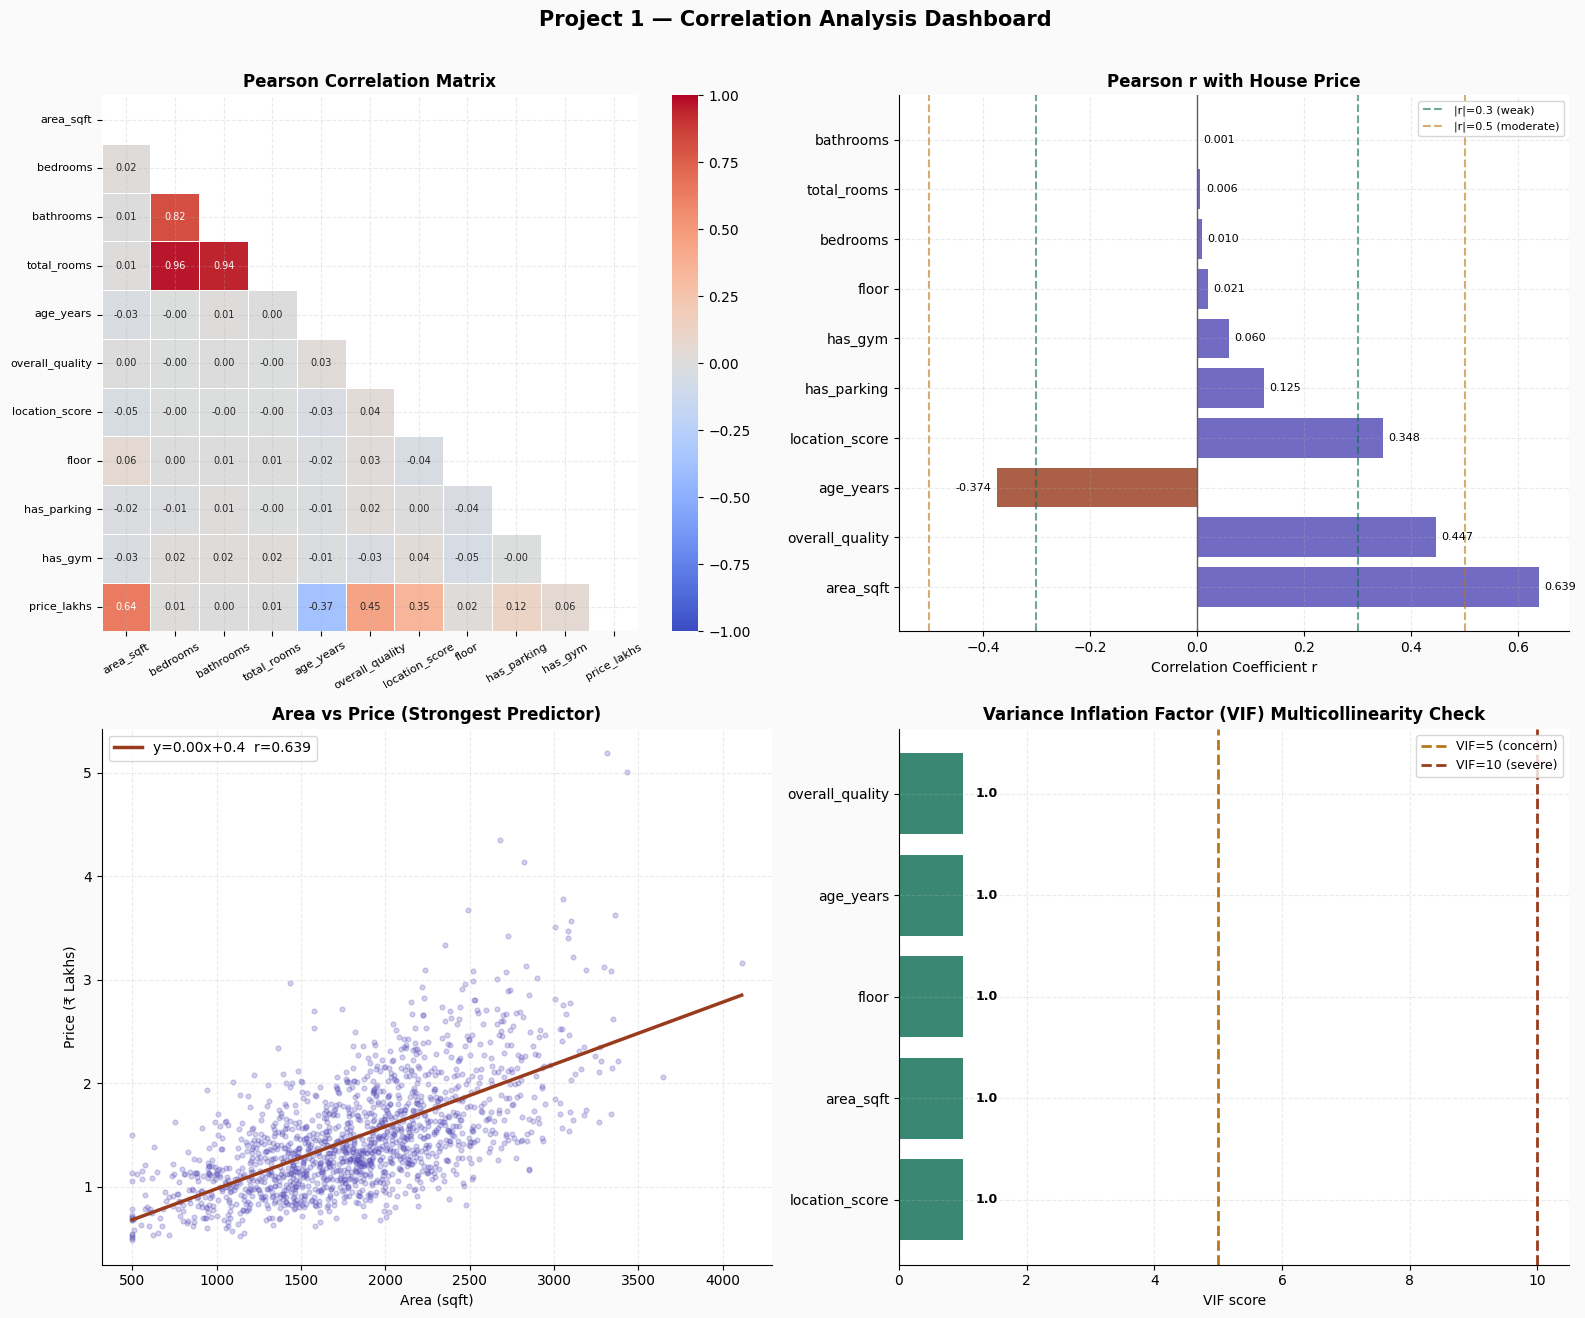

Dashboard saved: p1_correlation.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Project 1 — Correlation Analysis Dashboard', fontsize=15, fontweight='bold', y=1.01)

# P1: Pearson heatmap - ஒவ்வொரு Feature-க்கும் மற்ற Feature-க்கும் உள்ள Correlation.
# 🔴 சிவப்பு - Positive Correlation ஒன்று அதிகரித்தால் மற்றதும் அதிகரிக்கும்.
# 🔵 நீலம் - Negative Correlation ஒன்று அதிகரித்தால் மற்றது குறையும்.
# ⚪ வெள்ளை - No Correlation தொடர்பு இல்லை.
# ex : area_sqft ↔ price_lakhs = 0.64 Area அதிகரித்தால் Price அதிகரிக்கும். , age_years ↔ price_lakhs = -0.37 Age அதிகரித்தால் Price குறைகிறது.
mask1 = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask1, ax=axes[0,0],
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size':7})
axes[0,0].set_title('Pearson Correlation Matrix', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0,0].tick_params(axis='y', labelsize=8)

# P2: Correlation bar — features vs price -ஒவ்வொரு Feature-ம் Price-ஐ எவ்வளவு பாதிக்கிறது.
# Bar வலப்பக்கம் - Positive Correlation Feature ↑ → Price ↑
# Bar இடப்பக்கம் - Negative Correlation Feature ↑ → Price ↓

feats_sorted = price_pearson.index.tolist()
vals_sorted  = price_pearson.values
bar_colors   = [CORAL if v<0 else PURPLE for v in vals_sorted]
bars2 = axes[0,1].barh(feats_sorted, vals_sorted, color=bar_colors, alpha=0.82)
axes[0,1].axvline(0, color=DGRAY, linewidth=1)
axes[0,1].axvline(0.3,  color=TEAL, linewidth=1.5, linestyle='--', alpha=0.6, label='|r|=0.3 (weak)')
axes[0,1].axvline(-0.3, color=TEAL, linewidth=1.5, linestyle='--', alpha=0.6)
axes[0,1].axvline(0.5,  color=AMBER, linewidth=1.5, linestyle='--', alpha=0.6, label='|r|=0.5 (moderate)')
axes[0,1].axvline(-0.5, color=AMBER, linewidth=1.5, linestyle='--', alpha=0.6)
for bar, v in zip(bars2, vals_sorted):
    axes[0,1].text(v + 0.01 if v>=0 else v - 0.01, bar.get_y()+bar.get_height()/2,
                   f'{v:.3f}', va='center', ha='left' if v>=0 else 'right', fontsize=8)
axes[0,1].set_title('Pearson r with House Price', fontweight='bold')
axes[0,1].set_xlabel('Correlation Coefficient r'); axes[0,1].legend(fontsize=8)

# P3: Scatter — area vs price (strongest predictor) - ஒவ்வொரு Dot = ஒரு வீடு.
# X Axis - Area (sqft) ; Y Axis - Price (Lakhs) ; சிவப்பு கோடு - Regression Line : Best Fit Line
# எப்படி படிப்பது? Dots மேலே செல்லும் Pattern இருந்தால்: Area ↑, Price ↑
# உங்கள் Dataset: Area அதிகரிக்கும்போது Price கூடுகிறது. அதனால்: Strong Positive Correlation காணப்படும். r = 0.639 ,அர்த்தம்: Strong Relationship

axes[1,0].scatter(df_house['area_sqft'], df_house['price_lakhs'],
                  color=PURPLE, alpha=0.25, s=12)
m, b, r, p, se = stats.linregress(df_house['area_sqft'], df_house['price_lakhs'])
x_line = np.linspace(df_house['area_sqft'].min(), df_house['area_sqft'].max(), 100)
axes[1,0].plot(x_line, m*x_line+b, color=CORAL, linewidth=2.5,
               label=f'y={m:.2f}x+{b:.1f}  r={r:.3f}')
axes[1,0].set_title('Area vs Price (Strongest Predictor)', fontweight='bold')
axes[1,0].set_xlabel('Area (sqft)'); axes[1,0].set_ylabel('Price (₹ Lakhs)')
axes[1,0].legend(fontsize=10)

# P4: VIF bar chart - Features ஒன்றுக்கொன்று Duplicate Information கொடுக்கிறதா?
# Green (TEAL) - VIF < 5 பிரச்சினை இல்லை.
# Orange (AMBER) - 5 < VIF < 10 Warning.
# Red (CORAL) - VIF > 10 Severe Multicollinearity.

vif_colors = [CORAL if v>10 else AMBER if v>5 else TEAL for v in vif_data['VIF']]
axes[1,1].barh(vif_data['Feature'], vif_data['VIF'],
               color=vif_colors, alpha=0.82)
axes[1,1].axvline(5,  color=AMBER, linewidth=2, linestyle='--', label='VIF=5 (concern)')
axes[1,1].axvline(10, color=CORAL, linewidth=2, linestyle='--', label='VIF=10 (severe)')
for i, (feat, vif) in enumerate(zip(vif_data['Feature'], vif_data['VIF'])):
    axes[1,1].text(vif+0.2, i, f'{vif:.1f}', va='center', fontsize=9, fontweight='bold')
axes[1,1].set_title('Variance Inflation Factor (VIF) Multicollinearity Check', fontweight='bold')
axes[1,1].set_xlabel('VIF score'); axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p1_correlation.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p1_correlation.png")


---
---
# 📊 Project 2 — OLS Multiple Regression
## House Price Prediction with statsmodels

---

### What is OLS Regression?
> நாம் ஒரு வீட்டின் விலையை (House Price) கணிக்க வேண்டும். 
வீட்டின்: 
Size (சதுர அடி), 
Bedrooms, 
Age  இவற்றை வைத்து Price-ஐ predict பண்ணுறோம்.
OLS Regression ஒரு best-fit line கண்டுபிடிக்கும். Formula: Price=β0+β1(Size)+β2(Bedrooms)+β3(Age)

> 📌 **Tamil:** "OLS = Ordinary Least Squares. Data points-க்கும் regression line-க்கும் இடையே உள்ள  
> squared distances-ஐ minimize பண்றது. Formula: Y = β₀ + β₁X₁ + β₂X₂ + ... + ε"

### Key Output to Interpret

| Metric | Meaning | Good value |
|--------|---------|-----------|
| **R²** | % variance explained by model | > 0.70 |
| **Adj R²** | R² penalised for extra features | Close to R² |
| **F-statistic** | Is the whole model significant? | p < 0.05 |
| **p-value (coef)** | Is this feature significant? | < 0.05 |
| **Coefficient β** | Effect of 1 unit change on Y | Context-dependent |
| **95% CI** | Plausible range for true β | Excludes 0 = significant |


---

1️⃣ R² (R Square):Model எவ்வளவு நன்றாக target-ஐ explain செய்கிறது என்பதைக் காட்டும்.

Example: R² = 0.85 அப்படின்னா

👉 House Price-ல் நடக்கும் மாற்றங்களில் 85% காரணத்தை model explain பண்ணுகிறது

👉 மீதமுள்ள 15% unknown factors.

| R²    | Meaning      |
| ----- | ------------ |
| 0.20  | Poor 😔      |
| 0.50  | Average 🙂   |
| 0.70+ | Good 👍      |
| 0.90+ | Excellent 🌟 |

| Features                                         | R²    |
| ------------------------------------------------ | ----- |
| Size                                             | 0.80  |
| Size + Bedrooms                                  | 0.85  |
| Size + Bedrooms + Color of Door                  | 0.851 |
| Size + Bedrooms + Door Color + Owner Name Length | 0.852 |

> 😅 Door Color, Owner Name Length ஆகியவை House Price-க்கு சம்பந்தமே இல்லாவிட்டாலும் R² கொஞ்சம் அதிகரிக்கலாம்.
அதனால் R² மட்டும் பார்த்தால் model super என்று தவறாக நினைக்கலாம். அதற்குத்தான் Adjusted R²

---

2️⃣ Adjusted R²:R² எப்போதும் feature சேர்த்தால் அதிகரிக்கும்.ஆனால் எல்லா features-மும் useful இல்லை.
Adjusted R² unnecessary features-க்கு penalty கொடுக்கும்.

> "இந்த புதிய feature உண்மையிலேயே உதவுதா? இல்லையா வெறும் noise ஆ?" உதவவில்லை என்றால் penalty கொடுக்கும்

Example
| Metric | Value |
| ------ | ----- |
| R²     | 0.90  |
| Adj R² | 0.89  |

👉 இரண்டும் close. அதனால் features useful. "Feature-கள் உண்மையிலேயே உதவுகிறதா?" என்பதைச் சொல்வது.

---

3️⃣ F-statistic: முழு model-ஏ useful-ஆ இல்லையா என்று test செய்யும்.

Question: "இந்த model random guess-ஐ விட நல்லதா?"

Example
| F-statistic | p-value |
| ------------------- |
| 0.0001      | 0.05        |

0.0001 < 0.05 : ✅ Model significant, "மொத்த model வேலை செய்கிறதா?" என்ற தேர்வு.

| p-value | Decision             |
| ------- | -------------------- |
| < 0.05  | Model Useful ✅       |
| > 0.05  | Model Useful இல்லை ❌ |

---

4️⃣ p-value (Coefficient) : ஒரு feature உண்மையில் price-ஐ affect செய்கிறதா?

| Feature  | p-value |
| -------- | ------- |
| Size     | 0.000   |
| Bedrooms | 0.030   |
| Age      | 0.600   |

Size : 0.000 < 0.05 ✅ Significant

Bedrooms : 0.030 < 0.05 ✅ Significant

Age: 0.600 > 0.05 ❌ Significant இல்லை

"இந்த feature முக்கியமா இல்லையா?" என்பதைக் கூறும்.

| p-value | Meaning           |
| ------- | ----------------- |
| < 0.05  | முக்கியம் ✅       |
| > 0.05  | முக்கியம் இல்லை ❌ |

---

5️⃣ Coefficient (β) : Feature 1 unit அதிகரித்தால் Price எவ்வளவு மாறும்?

| Feature  | Coefficient |
| -------- | ----------- |
| Size     | 5000        |
| Bedrooms | 200000      |
| Age      | -10000      |

Size = 5000 : Size 1 sq.ft அதிகரித்தால் 👉 Price ₹5000 அதிகரிக்கும்

Bedrooms = 200000 : 1 Bedroom கூடினால் 👉 Price ₹2,00,000 அதிகரிக்கும்

Age = -10000 : வீட்டின் வயது 1 வருடம் அதிகரித்தால் 👉 Price ₹10,000 குறையும்

Coefficient = "1 unit change-க்கு target எவ்வளவு மாறும்?"

---

6️⃣ 95% Confidence Interval (CI): True coefficient இந்த range-க்குள் இருக்க வாய்ப்பு அதிகம்.

| Feature | CI              |
| ------- | --------------- |
| Size    | [4000, 6000]    |
| Age     | [-15000, -5000] |
| Garage  | [-1000, 500]    |

Size: 4000 → 6000; 0 இல்லை => ✅ Significant

Age: -15000 → -5000; 0 இல்லை => ✅ Significant

Garage : -1000 → 500; 0 உள்ளே இருக்கிறது => ❌ Significant இல்லை

CI range-ல் 0 இல்லையென்றால் feature முக்கியமானது.

| CI contains 0? | Meaning           |
| -------------- | ----------------- |
| No             | Significant ✅     |
| Yes            | Not Significant ❌ |


In [7]:
# ── Feature selection after VIF check ─────────────────────────
# Dropping total_rooms (multicollinear with bedrooms+bathrooms) - VIF (Variance Inflation Factor) check செய்த பிறகு
# total_rooms feature remove செய்யப்படுகிறது. ஏன்? total_rooms ≈ bedrooms + bathrooms அதனால் duplicate information வருகிறது. இதை Multicollinearity என்பார்கள்.
features = ['area_sqft','bedrooms','bathrooms','age_years',
            'overall_quality','location_score','floor',
            'has_parking','has_gym']

X = sm.add_constant(df_house[features]) # OLS Regression-க்கு Constant (β₀) சேர்க்கப்படுகிறது.
y = df_house['price_lakhs'] # Predict செய்ய வேண்டிய value.

# ── Fit OLS model ──────Train Model -  OLS (Ordinary Least Squares) Best-fit regression line கண்டுபிடிக்கிறது.
model = sm.OLS(y, X).fit()

print("FULL OLS REGRESSION SUMMARY")
print(model.summary())

# ------------------------------------------------------------------

# | Output           | Value       | தமிழ் விளக்கம்                                 |
# | ---------------- | ----------- | ---------------------------------------------- |
# | Dep. Variable    | price_lakhs | Predict செய்யும் Target Variable (வீட்டு விலை) |
# | No. Observations | 1500        | மொத்தம் 1500 வீடுகளின் data பயன்படுத்தப்பட்டது |
# | Df Model         | 9           | 9 Features பயன்படுத்தப்பட்டுள்ளன               |
# | Df Residuals     | 1490        | மீதமுள்ள Degree of Freedom                     |

# | Metric            | Value | தமிழ் விளக்கம்                                  | Rule                              |
# | ----------------- | ----- | ----------------------------------------------- | --------------------------------- |
# | R²                | 0.884 | Model 88.4% Price variation-ஐ explain செய்கிறது | 0.70+ நல்லது ✅                    |
# | Adjusted R²       | 0.884 | தேவையில்லாத features இல்லை                      | R²-க்கு அருகில் இருக்க வேண்டும் ✅ |
# | F-statistic       | 1266  | மொத்த Model மிகவும் சக்திவாய்ந்தது              | பெரிய Value நல்லது ✅              |
# | Prob(F-statistic) | 0.00  | Model statistically significant                 | p < 0.05 ✅                        |

# 👉 இந்த Model House Price-ஐ predict செய்ய மிகவும் நல்லது. 👉 88.4% தகவலை explain செய்கிறது.

# ----------------------------------------------------------------------------------------

# | Feature         | Coef (β) | p-value | தமிழ் விளக்கம்                          | Significant? |
# | --------------- | -------- | ------- | --------------------------------------- | ------------ |
# | const           | -0.4925  | 0.000   | அனைத்து Features = 0 என்றால் Base Price | ✅            |
# | area_sqft       | 0.0006   | 0.000   | Area அதிகரித்தால் Price அதிகரிக்கும்    | ✅            |
# | bedrooms        | -0.0006  | 0.945   | Bedroom Count முக்கியமில்லை             | ❌            |
# | bathrooms       | 0.0004   | 0.974   | Bathroom Count முக்கியமில்லை            | ❌            |
# | age_years       | -0.0173  | 0.000   | வீடு பழையதாக இருந்தால் Price குறையும்   | ✅            |
# | overall_quality | 0.1185   | 0.000   | Quality அதிகரித்தால் Price அதிகரிக்கும் | ✅            |
# | location_score  | 0.0753   | 0.000   | நல்ல Location → அதிக Price              | ✅            |
# | floor           | -0.0011  | 0.126   | Floor முக்கியமில்லை                     | ❌            |
# | has_parking     | 0.1459   | 0.000   | Parking இருந்தால் Price அதிகரிக்கும்    | ✅            |
# | has_gym         | 0.0884   | 0.000   | Gym இருந்தால் Price அதிகரிக்கும்        | ✅            |

# Confidence Intervals (95%):

# | Feature         | CI               | Meaning                    |
# | --------------- | ---------------- | -------------------------- |
# | area_sqft       | [0.001, 0.001]   | Significant                |
# | bedrooms        | [-0.018, 0.017]  | 0 உள்ளது → Not Significant |
# | bathrooms       | [-0.021, 0.021]  | 0 உள்ளது → Not Significant |
# | age_years       | [-0.018, -0.016] | Significant                |
# | overall_quality | [0.114, 0.123]   | Significant                |
# | location_score  | [0.072, 0.079]   | Significant                |
# | floor           | [-0.002, 0.000]  | 0 உள்ளது → Not Significant |
# | has_parking     | [0.126, 0.166]   | Significant                |
# | has_gym         | [0.068, 0.109]   | Significant                |
# Rule: 👉 CI-க்குள் 0 வந்தால் Feature முக்கியமில்லை. 👉 CI-க்குள் 0 வரவில்லை என்றால் முக்கியமானது.

# | Feature         | t-value | தமிழ் விளக்கம்                          | Significant? |
# | --------------- | ------- | --------------------------------------- | ------------ |
# | const           | -15.518 | Base price negative side-ல் உள்ளது      | ✅            |
# | area_sqft       | 73.350  | Area price-ஐ மிகவும் வலுவாக பாதிக்கிறது | ✅            |
# | bedrooms        | -0.069  | எந்த தாக்கமும் இல்லை                    | ❌            |
# | bathrooms       | 0.033   | எந்த தாக்கமும் இல்லை                    | ❌            |
# | age_years       | -40.016 | Age அதிகரித்தால் Price குறைகிறது        | ✅            |
# | overall_quality | 50.055  | Quality மிக முக்கிய Feature             | ✅            |
# | location_score  | 39.146  | Location மிகவும் முக்கியம்              | ✅            |
# | floor           | -1.532  | Weak Effect                             | ❌            |
# | has_parking     | 14.055  | Parking நல்ல தாக்கம் தருகிறது           | ✅            |
# | has_gym         | 8.347   | Gym நல்ல தாக்கம் தருகிறது               | ✅            |
# Rule
# | t-value        | Meaning                      |
# | -------------- | ---------------------------- |
# | 0 க்கு அருகில் | Feature Impact இல்லை         |
# | ±2 க்கு மேல்   | Significant ✅                |
# | ±5 க்கு மேல்   | Strong Effect ✅              |
# | ±10 க்கு மேல்  | Very Strong Effect 🚀        |
# | ±30, ±50       | Extremely Strong Evidence 🔥 |

# 🎯 Standard Error என்றால் என்ன? : Coefficient (β) எவ்வளவு நம்பகமானது என்பதை காட்டும் அளவு. 
# அதாவது: "இந்த coefficient value எவ்வளவு stable-ஆ இருக்கிறது?" என்பதை சொல்கிறது.

# | Condition      | Meaning                        |
# | -------------- | ------------------------------ |
# | Std Err ≪ Coef | Coefficient நம்பகமானது ✅       |
# | Std Err ≈ Coef | Coefficient சந்தேகமானது ⚠️     |
# | Std Err > Coef | Coefficient நம்பகமானது இல்லை ❌ |
# | Small Std Err  | Stable Estimate ✅              |
# | Large Std Err  | Unstable Estimate ❌            |

# | Feature             | Coef    | Std Err    | தமிழ் விளக்கம்                                                        | Reliability |
# | ------------------- | ------- | ---------- | --------------------------------------------------------------------- | ----------- |
# | **area_sqft**       | 0.0006  | 0.00000833 | Error மிகவும் சிறியது. Area effect மிகவும் நம்பகமானது                 | ✅ Excellent |
# | **bedrooms**        | -0.0006 | 0.009      | Error coefficient-ஐ விட பல மடங்கு பெரியது. Bedroom effect நம்பகமில்லை | ❌ Poor      |
# | **bathrooms**       | 0.0004  | 0.011      | Error coefficient-ஐ விட மிகவும் பெரியது                               | ❌ Poor      |
# | **age_years**       | -0.0173 | ~0.000     | Error கிட்டத்தட்ட இல்லை. Age effect மிகவும் நம்பகமானது                | ✅ Excellent |
# | **overall_quality** | 0.1185  | 0.002      | Error மிகவும் குறைவு. Quality effect மிகவும் தெளிவானது                | ✅ Excellent |
# | **location_score**  | 0.0753  | 0.002      | Error குறைவு. Location effect நம்பகமானது                              | ✅ Excellent |
# | **floor**           | -0.0011 | 0.001      | Error coefficient-க்கு அருகில் உள்ளது                                 | ⚠️ Weak     |
# | **has_parking**     | 0.1459  | 0.010      | Error குறைவு. Parking effect நம்பகமானது                               | ✅ Good      |
# | **has_gym**         | 0.0884  | 0.011      | Error குறைவு. Gym effect நம்பகமானது                                   | ✅ Good      |


# ---------------------------------------------------------------------------------------------

# 📊 Jarque-Bera (JB) Test என்றால் என்ன? :இதுவும் Residuals Normal-ஆ இருக்கிறதா என்பதை பார்க்கும் மற்றொரு Test.
# ஆனால் இது இரண்டு விஷயங்களை பயன்படுத்துகிறது: Skewness, Kurtosis
# JB = 14183.337
# Prob(JB) = 0.00
# Hypothesis
# H₀	Residuals Normal Distribution
# H₁	Residuals Normal இல்லை
# Result: p-value = 0.00 => 0 < 0.05 => 👉 H₀ Reject => ❌ Residuals Normal இல்லை.

# 🤔 Omnibus & JB இரண்டும் ஏன்? : இரண்டும் ஒரே விஷயத்தை check செய்கின்றன:
# Residuals Normal-ஆ? ஆனால் முறைகள் வேறுபடும். Test	என்ன பார்க்கும்?
# Omnibus	Overall Normality
# Jarque-Bera	Skewness + Kurtosis மூலம் Normality
# Omnibus: 820.966
# Prob(Omnibus): 0.000
# | p-value | Decision                 |
# | ------- | ------------------------ |
# | > 0.05  | Residuals Normal ✅       |
# | < 0.05  | Residuals Normal இல்லை ❌ |
# Prob(Omnibus) = 0.000 => 0.000 < 0.05 👉 H₀ Reject 👉 Residuals Normal இல்லை ❌ Failed Normality Test

# Durbin-Watson = 2.096 => Residuals ஒன்றுக்கொன்று தொடர்பு இல்லாமல் இருக்கிறதா?
# | Value | Meaning              |
# | ----- | -------------------- |
# | ≈ 2   | Good ✅               |
# | < 1   | Positive Correlation |
# | > 3   | Negative Correlation | ✅ 2.096 Residuals Independent

# 📊 Skewness: Skew = 2.163 => Residuals Right Side-க்கு அதிகமாக நீள்கிறது.
# | Value | Meaning       |
# | ----- | ------------- |
# | 0     | Perfect       |
# | > 1   | Highly Skewed | ❌ Highly Right Skewed

# 📊 Kurtosis : Kurtosis = 17.43 => Outliers அதிகமா?
# | Value | Meaning    |
# | ----- | ---------- |
# | 3     | Normal     |
# | > 3   | Heavy Tail | ❌ நிறைய Outliers இருக்கலாம்

# 📊 Condition Number : Cond. No. = 1.26e+04 => Features ஒன்றோடொன்று அதிக தொடர்பு கொண்டிருக்கிறதா?
# | Condition Number | Meaning                |
# | ---------------- | ---------------------- |
# | < 30             | Good                   |
# | 30–100           | Warning                |
# | > 1000           | Multicollinearity Risk | ⚠️ 12,600 சில Features இன்னும் தொடர்புடையதாக இருக்கலாம்.
# மேலும் VIF Check செய்ய வேண்டும்.


FULL OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:            price_lakhs   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     1266.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:36:11   Log-Likelihood:                 376.12
No. Observations:                1500   AIC:                            -732.2
Df Residuals:                    1490   BIC:                            -679.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const         

In [ ]:
# ── Interpret the results in plain English ─────────────────────
# இந்த code OLS Summary-யை Business Language / Plain English-ல் புரியும் மாதிரி மாற்றுகிறது.
print("OLS COEFFICIENT INTERPRETATION")
print("="*65)
print()
params  = model.params
pvals   = model.pvalues
conf95  = model.conf_int()

print(f"  {'Feature':<20} {'Coeff (β)':>12} {'p-value':>10} {'95% CI':>22} {'Sig?':>6}")
print("  " + "-"*73)
for feat in features:
    b  = params[feat]
    p  = pvals[feat]
    lo = conf95.loc[feat, 0]
    hi = conf95.loc[feat, 1]
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"  {feat:<20} {b:>12.4f} {p:>10.4f}   ({lo:>7.3f}, {hi:>7.3f})  {sig:>6}")

print()
print(f"  R-squared      : {model.rsquared:.4f}  ({model.rsquared*100:.1f}% of price variance explained)")
print(f"  Adj R-squared  : {model.rsquared_adj:.4f}")
print(f"  F-statistic    : {model.fvalue:.2f}  p = {model.f_pvalue:.6f}")
print(f"  AIC            : {model.aic:.2f}")
print(f"  BIC            : {model.bic:.2f}")
print()
print("  PLAIN ENGLISH INTERPRETATION:")
print(f"  ► Each extra sqft adds ₹{params['area_sqft']*1000:.0f} (per 1000 sqft: ₹{params['area_sqft']*1000:.1f}L)")
print(f"  ► Each quality point adds ₹{params['overall_quality']:.2f}L")
print(f"  ► Each year older reduces price by ₹{abs(params['age_years'])*100:.0f}K")
print(f"  ► Parking adds ₹{params['has_parking']:.2f}L premium")
print(f"  ► Gym adds ₹{params['has_gym']:.2f}L premium")


# | Feature         | β (Coefficient) | p-value | 95% CI           | Significant? | தமிழ் விளக்கம்                          |
# | --------------- | --------------- | ------- | ---------------- | ------------ | --------------------------------------- |
# | area_sqft       | 0.0006          | 0.0000  | (0.001, 0.001)   | Yes          | Area அதிகரித்தால் Price அதிகரிக்கும்    |
# | bedrooms        | -0.0006         | 0.9448  | (-0.018, 0.017)  | No           | Bedroom Count முக்கியமில்லை             |
# | bathrooms       | 0.0004          | 0.9736  | (-0.021, 0.021)  | No           | Bathroom Count முக்கியமில்லை            |
# | age_years       | -0.0173         | 0.0000  | (-0.018, -0.016) | Yes          | House Age அதிகரித்தால் Price குறையும்   |
# | overall_quality | 0.1185          | 0.0000  | (0.114, 0.123)   | Yes          | Quality அதிகரித்தால் Price அதிகரிக்கும் |
# | location_score  | 0.0753          | 0.0000  | (0.072, 0.079)   | Yes          | Location நல்லதானால் Price அதிகரிக்கும்  |
# | floor           | -0.0011         | 0.1257  | (-0.002, 0.000)  | No           | Floor Number முக்கியமில்லை              |
# | has_parking     | 0.1459          | 0.0000  | (0.126, 0.166)   | Yes          | Parking இருந்தால் Price அதிகரிக்கும்    |
# | has_gym         | 0.0884          | 0.0000  | (0.068, 0.109)   | Yes          | Gym இருந்தால் Price அதிகரிக்கும்        |


# | Metric      | Value    | தமிழ் விளக்கம்                                         |
# | ----------- | -------- | ------------------------------------------------------ |
# | R²          | 0.8843   | House Price-ன் 88.4% மாற்றத்தை Model explain செய்கிறது |
# | Adj R²      | 0.8836   | தேவையில்லாத Features இல்லை                             |
# | F-statistic | 1265.69  | Model முழுவதும் மிகவும் Strong                         |
# | F p-value   | 0.000000 | Model Significant ✅                                    |

# | Item                | Explanation (தமிழ்) AIC (Akaike Information Criterion)                                                                                                                                       |
# | ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
# | **Define**          | Model எவ்வளவு நல்லது என்பதை அளக்கும் metric. Accuracy மட்டும் பார்க்காது; தேவையில்லாத features இருந்தால் penalty கொடுக்கும்.                               |
# | **Rule**            | **AIC குறைவாக (smaller) இருந்தால் நல்ல Model** ✅                                                                                                           |
# | **Good/Bad Value?** | தனியாக Good அல்லது Bad value இல்லை. மற்ற Models-உடன் compare செய்ய வேண்டும்.                                                                               |
# | **Your Value**      | **AIC = -732.24**                                                                                                                                          |
# | **Interpretation**  | இந்த value-ஐ மட்டும் வைத்து நல்லது/கெட்டது சொல்ல முடியாது. ஆனால் மற்ற Model-களை compare செய்யும்போது -732.24-ஐ விட குறைவான AIC இருந்தால் அது சிறந்த Model. |

# | Item                | Explanation (தமிழ்) BIC (Bayesian Information Criterion)                                                                               |
# | ------------------- | ---------------------------------------------------------------------------------------------------- |
# | **Define**          | AIC மாதிரி Model Quality-ஐ அளக்கும் metric. ஆனால் தேவையில்லாத features-க்கு அதிக penalty கொடுக்கும். |
# | **Rule**            | **BIC குறைவாக (smaller) இருந்தால் நல்ல Model** ✅                                                     |
# | **Good/Bad Value?** | தனியாக Good அல்லது Bad value இல்லை. மற்ற Models-உடன் compare செய்ய வேண்டும்.                         |
# | **Your Value**      | **BIC = -679.11**                                                                                    |
# | **Interpretation**  | இந்த value-ஐ மட்டும் வைத்து முடிவு செய்ய முடியாது. வேறு Model-களின் BIC-உடன் compare செய்ய வேண்டும். |

# | Output                                               | தமிழ் விளக்கம்                                                                                                                                                |
# | ---------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
# | **► Each extra sqft adds ₹1 (per 1000 sqft: ₹0.6L)** | வீட்டின் பரப்பளவு (Area) 1 sqft அதிகரித்தால் விலை சுமார் ₹1 அதிகரிக்கும். 1000 sqft அதிகரித்தால் வீட்டின் விலை சுமார் **₹0.6 லட்சம் (₹60,000)** அதிகரிக்கும். |
# | **► Each quality point adds ₹0.12L**                 | House Quality Score 1 point அதிகரித்தால் வீட்டின் விலை **₹0.12 லட்சம் (₹12,000)** அதிகரிக்கும்.                                                               |
# | **► Each year older reduces price by ₹2K**           | வீடு 1 வருடம் பழையதாகும் போது அதன் விலை சுமார் **₹2,000** குறையும்.                                                                                           |
# | **► Parking adds ₹0.15L premium**                    | Parking வசதி இருந்தால் வீட்டின் விலை கூடுதலாக **₹0.15 லட்சம் (₹15,000)** அதிகரிக்கும்.                                                                        |
# | **► Gym adds ₹0.09L premium**                        | Gym வசதி இருந்தால் வீட்டின் விலை கூடுதலாக **₹0.09 லட்சம் (₹9,000)** அதிகரிக்கும்.                                                                             |


OLS COEFFICIENT INTERPRETATION

  Feature                 Coeff (β)    p-value                 95% CI   Sig?
  -------------------------------------------------------------------------
  area_sqft                  0.0006     0.0000   (  0.001,   0.001)     Yes
  bedrooms                  -0.0006     0.9448   ( -0.018,   0.017)      No
  bathrooms                  0.0004     0.9736   ( -0.021,   0.021)      No
  age_years                 -0.0173     0.0000   ( -0.018,  -0.016)     Yes
  overall_quality            0.1185     0.0000   (  0.114,   0.123)     Yes
  location_score             0.0753     0.0000   (  0.072,   0.079)     Yes
  floor                     -0.0011     0.1257   ( -0.002,   0.000)      No
  has_parking                0.1459     0.0000   (  0.126,   0.166)     Yes
  has_gym                    0.0884     0.0000   (  0.068,   0.109)     Yes

  R-squared      : 0.8843  (88.4% of price variance explained)
  Adj R-squared  : 0.8836
  F-statistic    : 1265.69  p = 0.000000


In [ ]:
# ── Prediction example ───👉 Train செய்த OLS Model-ஐ பயன்படுத்தி புதிய வீடுகளின் விலையை Predict செய்வது
print("── House Price Prediction Examples ──")
print()

test_houses = pd.DataFrame({
    'const'           : [1, 1, 1],
    'area_sqft'       : [1200, 2500, 800],
    'bedrooms'        : [2,    4,    1  ],
    'bathrooms'       : [1,    3,    1  ],
    'age_years'       : [5,    15,   30 ],
    'overall_quality' : [7,    9,    5  ],
    'location_score'  : [8.5,  7.2,  4.0],
    'floor'           : [3,    12,   1  ],
    'has_parking'     : [1,    1,    0  ],
    'has_gym'         : [0,    1,    0  ],
})

predictions = model.predict(test_houses) # OLS Formula பயன்படுத்தப்படுகிறது. ஒவ்வொரு வீட்டிற்கும் Price கணக்கிடப்படுகிறது.
ci_pred     = model.get_prediction(test_houses).conf_int() # Prediction மட்டும் கொடுக்காமல் 95% Confidence Interval-யும் கணக்கிடுகிறது.
# Model சொல்கிறது: "இந்த வீட்டின் விலை ₹20L என்று நான் Predict செய்கிறேன்." 
# ஆனால் "உண்மையான விலை ₹18L முதல் ₹22L வரை இருக்கலாம்."

for i, (pred, (lo, hi)) in enumerate(zip(predictions, ci_pred)): # ஒவ்வொரு வீட்டிற்கும் Predicted Price, Lower Limit, Upper Limit எடுத்து print செய்கிறது.
    h = test_houses.iloc[i]
    print(f"  House {i+1}: {int(h['area_sqft'])}sqft, {int(h['bedrooms'])}BHK, "
          f"Quality={int(h['overall_quality'])}, Age={int(h['age_years'])}yr")
    print(f"    Predicted: ₹{pred:.2f}L  |  95% CI: (₹{lo:.2f}L, ₹{hi:.2f}L)")
    print()

# | House       | Area      | BHK | Bath | Age    | Quality | Location | Parking | Gym   | AI என்ன நினைக்கிறது?                                 | Price Impact               |
# | ----------- | --------- | --- | ---- | ------ | ------- | -------- | ------- | ----- | ---------------------------------------------------- | -------------------------- |
# | **House 1** | 1200 sqft | 2   | 1    | 5 yrs  | 7/10    | 8.5/10   | ✅ Yes   | ❌ No  | நல்ல Area, நல்ல Location, புதிய வீடு, Parking உள்ளது | 💰 நல்ல விலை கிடைக்கும்    |
# | **House 2** | 2500 sqft | 4   | 3    | 15 yrs | 9/10    | 7.2/10   | ✅ Yes   | ✅ Yes | பெரிய வீடு, Premium Quality, Parking + Gym உள்ளது    | 👑 அதிக விலை கிடைக்கும்    |
# | **House 3** | 800 sqft  | 1   | 1    | 30 yrs | 5/10    | 4/10     | ❌ No    | ❌ No  | சிறிய வீடு, பழைய வீடு, வசதிகள் இல்லை                 | 😔 குறைந்த விலை கிடைக்கும் |

# | House          | Predicted Price (₹L) | 95% CI (₹L)          | தமிழ் விளக்கம்                                                                                                                                                                                    |
# | -------------- | -------------------- | -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
# | **🏠 House 1** | **₹1.77L**           | **(₹1.73L, ₹1.80L)** | 1200 sqft, நல்ல Location (8.5), Quality 7, Parking உள்ளது, Age 5 வருடம். அதனால் Model இந்த வீட்டின் விலையை ₹1.77L என்று கணிக்கிறது. உண்மையான விலை ₹1.73L முதல் ₹1.80L வரை இருக்க வாய்ப்பு அதிகம். |
# | **🏠 House 2** | **₹2.60L**           | **(₹2.57L, ₹2.63L)** | 2500 sqft, Quality 9, Parking + Gym இரண்டும் உள்ளது. இந்த மூன்று வீடுகளில் மிக உயர்ந்த விலை இதற்கே வருகிறது. உண்மையான விலை ₹2.57L முதல் ₹2.63L வரை இருக்கலாம்.                                    |
# | **🏠 House 3** | **₹0.37L**           | **(₹0.33L, ₹0.41L)** | 800 sqft, Quality 5, Location 4, Parking இல்லை, Gym இல்லை, Age 30 வருடம். அதனால் Model குறைந்த விலையை Predict செய்கிறது. உண்மையான விலை ₹0.33L முதல் ₹0.41L வரை இருக்கலாம்.                        |


── House Price Prediction Examples ──

  House 1: 1200sqft, 2BHK, Quality=7, Age=5yr
    Predicted: ₹1.77L  |  95% CI: (₹1.73L, ₹1.80L)

  House 2: 2500sqft, 4BHK, Quality=9, Age=15yr
    Predicted: ₹2.60L  |  95% CI: (₹2.57L, ₹2.63L)

  House 3: 800sqft, 1BHK, Quality=5, Age=30yr
    Predicted: ₹0.37L  |  95% CI: (₹0.33L, ₹0.41L)



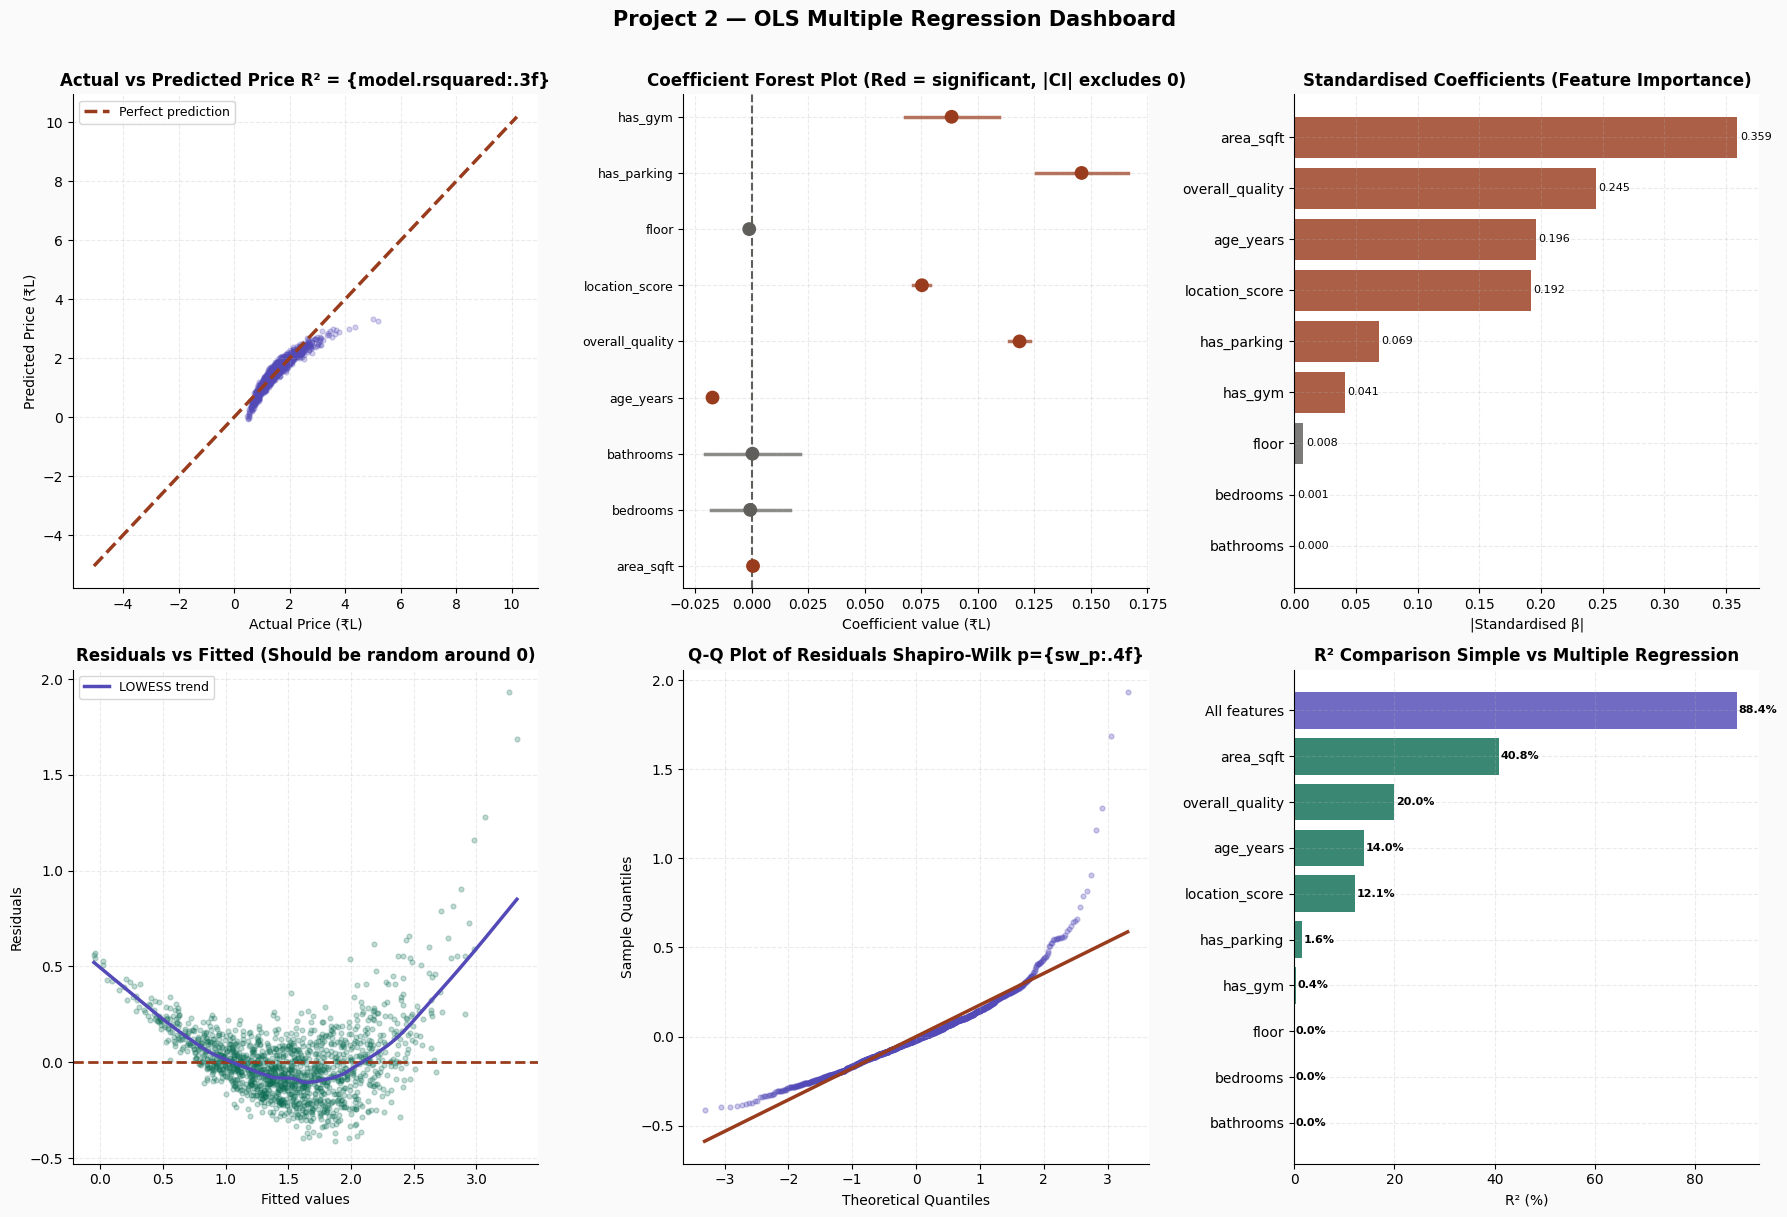

Dashboard saved: p2_ols_regression.png


In [ ]:
# ── OLS Dashboard ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Project 2 — OLS Multiple Regression Dashboard', fontsize=15, fontweight='bold', y=1.01)

y_pred   = model.predict()
residuals= model.resid

# P1: Actual vs Predicted
# | Chart Object       | தமிழ் பெயர்             | என்ன குறிக்கிறது?             | உங்கள் Chart-ல்     |
# | ------------------ | ----------------------- | ----------------------------- | ------------------- |
# | 🔵 Blue Dot        | Data Point              | ஒரு வீடு                      | ஒரு Dot = ஒரு House |
# | 🔴 Red Dashed Line | Perfect Prediction Line | Actual = Predicted            | Ideal Line          |
# | X-Axis             | Actual Price            | உண்மையான விலை                 | ₹L                  |
# | Y-Axis             | Predicted Price         | Model கணித்த விலை             | ₹L                  |
# | Dot Line மேல்      | Over Prediction         | Model அதிகமாக Predict செய்தது | சில Points          |
# | Dot Line கீழ்      | Under Prediction        | Model குறைவாக Predict செய்தது | சில Points          |
# | Dot Line அருகில்   | Good Prediction         | Prediction சரியானது           | பெரும்பாலான Points  |
# | R² = 0.884         | Model Fit               | 88.4% Explain செய்கிறது       | ✅ நல்லது            |

ax1 = axes[0,0]
ax1.scatter(y, y_pred, color=PURPLE, alpha=0.25, s=12)
lim = [min(y.min(),y_pred.min())-5, max(y.max(),y_pred.max())+5]
ax1.plot(lim, lim, color=CORAL, linewidth=2.5, linestyle='--', label='Perfect prediction')
ax1.set_title('Actual vs Predicted Price R² = {model.rsquared:.3f}', fontweight='bold')
ax1.set_xlabel('Actual Price (₹L)'); ax1.set_ylabel('Predicted Price (₹L)')
ax1.legend(fontsize=9)

# P2: Coefficient plot (forest plot)
# | Chart Object           | தமிழ் பெயர்         | என்ன குறிக்கிறது?   | உங்கள் Chart  |
# | ---------------------- | ------------------- | ------------------- | ------------- |
# | 🔴 Dot                 | Coefficient         | Feature Effect Size | β Value       |
# | ➖ Horizontal Line      | Confidence Interval | 95% CI              | Lower → Upper |
# | │ Vertical Dashed Line | Zero Effect Line    | Effect = 0          | Reference     |
# | Red Dot                | Significant Feature | p < 0.05            | Yes           |
# | Grey Dot               | Weak Feature        | p > 0.05            | No            |
# | Dot Right Side         | Positive Effect     | Price அதிகரிக்கும்  | Parking       |
# | Dot Left Side          | Negative Effect     | Price குறையும்      | Age           |
# | X-Axis                 | Coefficient Value   | β Value             | ₹L            |
# | Y-Axis                 | Features            | Variables           | Area, Age...  |

# | Feature         | Dot Position        | Meaning         |
# | --------------- | ------------------- | --------------- |
# | area_sqft       | 0 அருகில் (சிறிய β) | Positive        |
# | age_years       | Left Side           | Negative        |
# | overall_quality | Right Side          | Positive        |
# | location_score  | Right Side          | Positive        |
# | has_parking     | Far Right           | Strong Positive |
# | has_gym         | Right Side          | Positive        |
# | bedrooms        | 0 அருகில்           | Weak            |
# | bathrooms       | 0 அருகில்           | Weak            |
# | floor           | 0 அருகில்           | Weak            |

ax2 = axes[0,1]
feat_labels = features
coefs = [params[f] for f in feat_labels]
cis_lo = [conf95.loc[f,0] for f in feat_labels]
cis_hi = [conf95.loc[f,1] for f in feat_labels]
colors_coef = [CORAL if p<0.05 else DGRAY for p in [pvals[f] for f in feat_labels]]
ax2.scatter(coefs, range(len(feat_labels)), color=colors_coef, s=80, zorder=5)
for i, (lo, hi, c) in enumerate(zip(cis_lo, cis_hi, coefs)):
    ax2.plot([lo, hi], [i, i], color=colors_coef[i], linewidth=2.5, alpha=0.7)
ax2.axvline(0, color=DGRAY, linewidth=1.5, linestyle='--')
ax2.set_yticks(range(len(feat_labels)))
ax2.set_yticklabels(feat_labels, fontsize=9)
ax2.set_title('Coefficient Forest Plot (Red = significant, |CI| excludes 0)', fontweight='bold')
ax2.set_xlabel('Coefficient value (₹L)')

# P3: Feature importance (standardized coefficients)
# | Chart Object      | தமிழ் பெயர்        | Meaning                  |
# | ----------------- | ------------------ | ------------------------ |
# | 🟫 Horizontal Bar | Feature Importance | Feature Power            |
# | Bar Length        | Importance Size    | நீளம் அதிகம் → முக்கியம் |
# | Value Label       | β Value            | Importance Number        |
# | Red Bar           | Significant        | p < 0.05                 |
# | Grey Bar          | Not Significant    | p > 0.05                 |
# | X-Axis            | Standardised β     | Importance               |
# | Y-Axis            | Features           | Variables                |
# | Bar             | Meaning        |
# | --------------- | -------------- |
# | area_sqft       | Longest Bar 🏆 |
# | overall_quality | 2nd Longest    |
# | age_years       | 3rd            |
# | location_score  | 4th            |
# | has_parking     | Small          |
# | has_gym         | Small          |
# | floor           | Tiny           |
# | bedrooms        | Tiny           |
# | bathrooms       | Tiny           |


ax3 = axes[0,2]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_house[features])
X_sc_df  = pd.DataFrame(X_scaled, columns=features)
X_sc_sm  = sm.add_constant(X_sc_df)
model_sc = sm.OLS(y, X_sc_sm).fit()
std_coefs = model_sc.params[features].abs().sort_values(ascending=True)
bars3 = ax3.barh(std_coefs.index, std_coefs.values,
                  color=[CORAL if model_sc.pvalues[f]<0.05 else DGRAY
                         for f in std_coefs.index], alpha=0.82)
for bar, v in zip(bars3, std_coefs.values):
    ax3.text(v+0.002, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=8)
ax3.set_title('Standardised Coefficients (Feature Importance)', fontweight='bold')
ax3.set_xlabel('|Standardised β|')

# P4: Residuals vs Fitted
# | Chart Object       | தமிழ் பெயர்     | Meaning            |
# | ------------------ | --------------- | ------------------ |
# | 🟢 Green Dot       | Residual Point  | ஒரு வீட்டின் Error |
# | 🔴 Horizontal Line | Zero Error Line | Error = 0          |
# | 🟣 Curved Line     | LOWESS Trend    | Error Trend        |
# | X-Axis             | Fitted Value    | Predicted Price    |
# | Y-Axis             | Residual        | Actual − Predicted |

# | Position     | Meaning            | 
# | ------------ | ------------------ |
# | Above 0 Line | Actual > Predicted |
# | Below 0 Line | Actual < Predicted |
# | Near 0       | Good Prediction    |
# | Far from 0   | Large Error        |

# | Object      | Observation        |
# | ----------- | ------------------ |
# | Green Dots  | Random இல்லை       |
# | Purple Line | U Shape            |
# | Meaning     | Non-linear Pattern |

ax4 = axes[1,0]
ax4.scatter(y_pred, residuals, color=TEAL, alpha=0.25, s=12)
ax4.axhline(0, color=CORAL, linewidth=2, linestyle='--')
lowess = sm.nonparametric.lowess(residuals, y_pred, frac=0.2)
ax4.plot(lowess[:,0], lowess[:,1], color=PURPLE, linewidth=2.5, label='LOWESS trend')
ax4.set_title('Residuals vs Fitted (Should be random around 0)', fontweight='bold')
ax4.set_xlabel('Fitted values'); ax4.set_ylabel('Residuals')
ax4.legend(fontsize=9)

# P5: Q-Q plot of residuals
# | Chart Object | தமிழ் பெயர்              | Meaning         |
# | ------------ | ------------------------ | --------------- |
# | 🔵 Dot       | Residual Quantile        | Actual Residual |
# | 🔴 Line      | Normal Distribution Line | Ideal Normality |
# | X-Axis       | Theoretical Quantile     | Expected Normal |
# | Y-Axis       | Sample Quantile          | Actual Data     |

# | Dot Position             | Meaning         |
# | ------------------------ | --------------- |
# | Line மீது                | Normal          |
# | Line அருகில்             | Nearly Normal   |
# | Line விட்டு விலகினால்    | Not Normal      |
# | Tail பகுதியில் விலகினால் | Outliers / Skew |

# | Observation   | Meaning          |
# | ------------- | ---------------- |
# | Middle Points | OK               |
# | Upper Tail    | Strong Deviation |
# | Lower Tail    | Deviation        |
# | Result        | ❌ Normal இல்லை   |

ax5 = axes[1,1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax5.scatter(osm, osr, color=PURPLE, alpha=0.3, s=12)
ax5.plot(osm, slope*np.array(osm)+intercept, color=CORAL, linewidth=2.5)
_, sw_p = stats.shapiro(residuals[:200])
ax5.set_title('Q-Q Plot of Residuals Shapiro-Wilk p={sw_p:.4f}', fontweight='bold')
ax5.set_xlabel('Theoretical Quantiles'); ax5.set_ylabel('Sample Quantiles')

# P6: R-squared comparison: simple vs multiple regression
# | Chart Object  | தமிழ் பெயர்          | Meaning             |
# | ------------- | -------------------- | ------------------- |
# | 🟩 Green Bar  | Single Feature Model | ஒரு Feature மட்டும் |
# | 🟪 Purple Bar | Full Model           | அனைத்து Features    |
# | Bar Length    | Explained Variance   | R²                  |
# | Value Label   | R² %                 | Percentage          |
# | X-Axis        | R² (%)               | Explained Variance  |
# | Y-Axis        | Features             | Variables           |

# | Bar                  | Meaning             |
# | -------------------- | ------------------- |
# | Purple Bar (88.4%)   | Best Model          |
# | Area Bar (40.8%)     | Best Single Feature |
# | Quality Bar (20%)    | 2nd Best            |
# | Age Bar (14%)        | 3rd Best            |
# | Location Bar (12.1%) | 4th Best            |
# | Parking Bar (1.6%)   | Weak Alone          |
# | Gym Bar (0.4%)       | Very Weak Alone     |


ax6 = axes[1,2]
models_r2 = {}
for feat in features:
    Xs = sm.add_constant(df_house[[feat]])
    ms = sm.OLS(y, Xs).fit()
    models_r2[feat] = ms.rsquared
models_r2['All features'] = model.rsquared
sorted_r2 = sorted(models_r2.items(), key=lambda x: x[1])
names_r2  = [x[0] for x in sorted_r2]
vals_r2   = [x[1] for x in sorted_r2]
bar_cols6 = [PURPLE if n=='All features' else TEAL for n in names_r2]
bars6 = ax6.barh(names_r2, [v*100 for v in vals_r2], color=bar_cols6, alpha=0.82)
for bar, v in zip(bars6, vals_r2):
    ax6.text(v*100+0.3, bar.get_y()+bar.get_height()/2,
             f'{v*100:.1f}%', va='center', fontsize=8, fontweight='bold')
ax6.set_title('R² Comparison Simple vs Multiple Regression', fontweight='bold')
ax6.set_xlabel('R² (%)')

plt.tight_layout()
plt.savefig('p2_ols_regression.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p2_ols_regression.png")


---
---
# 🔬 Project 3 — Residual Diagnostics
## Is Our Regression Model Valid?

>Regression Model Train செய்த பிறகு,"இந்த Model-ஐ நம்பலாமா?" "OLS Assumptions satisfy ஆகிறதா?"
என்பதை Check செய்வதற்கான Process தான் Residual Diagnostics

---

### The 4 OLS Assumptions

> 📌 **Tamil:** "OLS model valid-ஆக இருக்க 4 assumptions satisfy ஆகணும்.  
> இந்த assumptions violate ஆனால் model predictions trustworthy இல்லை."

| # | Assumption | Test | Violation |
|---|-----------|------|-----------|
| 1 | **Linearity** | Residuals vs Fitted | Pattern in residuals |
| 2 | **Normality of residuals** | Q-Q plot, Shapiro-Wilk | Non-normal residuals |
| 3 | **Homoscedasticity** (equal variance) | Breusch-Pagan test | Funnel shape in residuals |
| 4 | **No autocorrelation** | Durbin-Watson test | DW ≠ 2 |

---

| Assumption                    | Define (வரையறை)                                                 | Example (உதாரணம்)                                  | எப்படி Check செய்வது?                        | Rule (நியதி)                                | Good Result ✅                 | Bad Result ❌                  |
| ----------------------------- | --------------------------------------------------------------- | -------------------------------------------------- | -------------------------------------------- | ------------------------------------------- | ----------------------------- | ----------------------------- |
| **1. Linearity**              | X மற்றும் Y இடையே நேரியல் (Straight Line) உறவு இருக்க வேண்டும்  | Area அதிகரித்தால் Price நேராக அதிகரிக்க வேண்டும்   | Residuals vs Fitted Plot                     | Residuals Random Scatter ஆக இருக்க வேண்டும் | Random Cloud around 0         | U Shape, Curve Shape, Pattern |
| **2. Normality of Residuals** | Residuals Normal Distribution Follow செய்ய வேண்டும்             | Errors Bell Shape Distribution போல இருக்க வேண்டும் | Q-Q Plot, Shapiro-Wilk, Jarque-Bera, Omnibus | p > 0.05 → Normal                           | Points Line அருகில் இருக்கும் | Points Line-ஐ விட்டு விலகும்  |
| **3. Homoscedasticity**       | Errors எல்லா Predictions-க்கும் ஒரே Variance-ல் இருக்க வேண்டும் | ₹1L House Error ≈ ₹5L House Error                  | Residuals vs Fitted, Breusch-Pagan Test      | p > 0.05 → Equal Variance                   | Equal Spread                  | Funnel Shape                  |
| **4. No Autocorrelation**     | ஒரு Residual மற்ற Residual-ஐ Influence செய்யக்கூடாது            | Error Sequence Random ஆக இருக்க வேண்டும்           | Durbin-Watson Test                           | DW ≈ 2                                      | 1.5 – 2.5                     | <1.5 அல்லது >2.5              |


| Assumption       | Test          | Value    | Meaning                    |
| ---------------- | ------------- | -------- | -------------------------- |
| Linearity        | Residual Plot | Random   | ✅ Linear                   |
| Linearity        | Residual Plot | U Shape  | ❌ Non-linear               |
| Normality        | Shapiro-Wilk  | p > 0.05 | ✅ Normal                   |
| Normality        | Shapiro-Wilk  | p < 0.05 | ❌ Not Normal               |
| Normality        | Jarque-Bera   | p > 0.05 | ✅ Normal                   |
| Normality        | Jarque-Bera   | p < 0.05 | ❌ Not Normal               |
| Normality        | Omnibus       | p > 0.05 | ✅ Normal                   |
| Normality        | Omnibus       | p < 0.05 | ❌ Not Normal               |
| Homoscedasticity | Breusch-Pagan | p > 0.05 | ✅ Equal Variance           |
| Homoscedasticity | Breusch-Pagan | p < 0.05 | ❌ Unequal Variance         |
| Autocorrelation  | Durbin-Watson | ≈ 2      | ✅ No Autocorrelation       |
| Autocorrelation  | Durbin-Watson | < 1.5    | ❌ Positive Autocorrelation |
| Autocorrelation  | Durbin-Watson | > 2.5    | ❌ Negative Autocorrelation |



In [ ]:
# நாம் OLS Regression Model உருவாக்கி விட்டோம். இப்போது Model-ஐ பார்த்து: 🤔 "இந்த Model-ஐ நம்பலாமா?" என்று 4 முக்கியமான Assumptions-ஐ Check செய்கிறது.

from statsmodels.stats.diagnostic import (het_breuschpagan, het_white,
                                           linear_reset, acorr_ljungbox)

residuals = model.resid  # => Residuals = Error , Residual = Actual Price − Predicted Price
y_pred    = model.predict() # Model கணித்த Price-களை எடுக்கிறது.
X_with_c  = sm.add_constant(df_house[features]) # Regression Tests செய்ய Constant Column சேர்க்கப்படுகிறது.

print("RESIDUAL DIAGNOSTIC TESTS")
print("="*60)
print()

# 1. Normality (Shapiro-Wilk on sample) Residuals Normal Distribution-ல் இருக்கிறதா?
# | Metric  | Value  | P-value | Interpretation |
# | ------- | ------ | -------- | -------------- |
# | W       | 0.7622 | > 0.05   | Normal residuals |
# | p-value | 0.0000 | < 0.05   | NOT normal |  
# my result: p = 0.0000 => 0.05-ஐ விட குறைவு => so "Residuals Normal Distribution-ஐ Follow செய்யவில்லை."❌ Assumption Failed 
# Suggested Fix: log(price) Transformation செய்யலாம்.

sample_res = residuals[:200]
sw_stat, sw_p = stats.shapiro(sample_res)
print(f"  1. NORMALITY OF RESIDUALS (Shapiro-Wilk, n=200)")
print(f"     W = {sw_stat:.4f}  p = {sw_p:.4f}")
print(f"     Result: {'Normal residuals' if sw_p>0.05 else 'NOT normal — consider log transform'}")
print()

# 2. Homoscedasticity (Breusch-Pagan) Errors எல்லா Price Range-க்கும் ஒரே Variance-ல் இருக்கிறதா?
# | Metric  | Value  | P-value | Interpretation |
# | ------- | ------ | -------- | -------------- |
# | LM      | 80.6116 | > 0.05   | Homoscedastic (equal variance) |
# | p-value | 0.0000 | < 0.05   | Heteroscedastic (variance changes with fitted values) |
# சிறிய வீடுகளுக்கு Error குறைவு பெரிய வீடுகளுக்கு Error அதிகம்

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_c)
print(f"  2. HOMOSCEDASTICITY (Breusch-Pagan test)")
print(f"     LM = {bp_stat:.4f}  p = {bp_p:.4f}")
print(f"     Result: {'Equal variance (homoscedastic)' if bp_p>0.05 else 'Heteroscedastic — variance changes with fitted values'}")
print()

# 3. Autocorrelation (Durbin-Watson) ஒரு Error அடுத்த Error-ஐ Influence செய்கிறதா?
# | Metric | Value  |
# | ------ | ------ |
# | DW     | 2.0959 |
# | DW    | Meaning                |
# | ----- | ---------------------- |
# | ≈ 2   | ✅ Good                 |
# | < 1.5 | ❌ Positive Correlation |
# | > 2.5 | ❌ Negative Correlation |Errors Random-ஆ இருக்கின்றன. ஒரு Error மற்ற Error-ஐ Follow செய்யவில்லை.✅ Assumption Passed

dw = durbin_watson(residuals)
print(f"  3. AUTOCORRELATION (Durbin-Watson)")
print(f"     DW = {dw:.4f}  (ideal: ~2.0, range 0-4)")
if dw < 1.5:
    print(f"     Result: Positive autocorrelation detected")
elif dw > 2.5:
    print(f"     Result: Negative autocorrelation detected")
else:
    print(f"     Result: No significant autocorrelation")
print()

# 4. Linearity (RESET test) Relationship உண்மையில் Linear-ஆ?
# | Metric  | Value     | p-value  | Interpretation |
# | ------- | --------- | --------- | -------------- |
# | F       | 1636.5003 | > 0.05    | Linear relationship OK |
# | p-value | 0.0000    | < 0.05    | Non-linearity detected — consider polynomial terms |

reset_result = linear_reset(model, power=3)
reset_stat = reset_result.statistic if hasattr(reset_result, 'statistic') else float(reset_result.fvalue)
reset_p    = reset_result.pvalue if hasattr(reset_result, 'pvalue') else float(reset_result.fpvalue)
print(f"  4. LINEARITY (RESET test)")
print(f"     F = {reset_stat:.4f}  p = {reset_p:.4f}")
print(f"     Result: {'Linear relationship OK' if reset_p>0.05 else 'Non-linearity detected — consider polynomial terms'}")
print()
print("  OVERALL MODEL VALIDITY:")
issues = []
if sw_p < 0.05:   issues.append("non-normal residuals → use log(price)")
if bp_p < 0.05:   issues.append("heteroscedasticity → use robust std errors")
if dw < 1.5 or dw > 2.5: issues.append("autocorrelation")
if reset_p < 0.05: issues.append("non-linearity → add polynomial terms")
if issues:
    for issue in issues: print(f"    ⚠️  {issue}")
else:
    print(f"    All assumptions met — model is valid!")

# Final Conclusion:
# இந்த Model Price-ஐ நன்றாக Predict செய்கிறது (R² = 88.4%), ஆனால் OLS Assumptions-ல் 3 Fail ஆகியுள்ளன. 
# அதனால் Model-ஐ மேம்படுத்த log(price), robust standard errors, மற்றும் polynomial features பயன்படுத்தலாம். 📈🏠

RESIDUAL DIAGNOSTIC TESTS

  1. NORMALITY OF RESIDUALS (Shapiro-Wilk, n=200)
     W = 0.7622  p = 0.0000
     Result: NOT normal — consider log transform

  2. HOMOSCEDASTICITY (Breusch-Pagan test)
     LM = 80.6116  p = 0.0000
     Result: Heteroscedastic — variance changes with fitted values

  3. AUTOCORRELATION (Durbin-Watson)
     DW = 2.0959  (ideal: ~2.0, range 0-4)
     Result: No significant autocorrelation

  4. LINEARITY (RESET test)
     F = 1636.5003  p = 0.0000
     Result: Non-linearity detected — consider polynomial terms

  OVERALL MODEL VALIDITY:
    ⚠️  non-normal residuals → use log(price)
    ⚠️  heteroscedasticity → use robust std errors
    ⚠️  non-linearity → add polynomial terms


In [ ]:
# ── Log transformation to fix skewness ────────────────────────
print("LOG TRANSFORMATION — Fixing skewed price distribution") - # Price Values மிகவும் பெரிய Range-ல் இருந்தால் Log Function மூலம் Compress செய்வது.
print()
# 👉 House Prices மிகவும் Skewed-ஆ இருந்தது. அதனால் Price-ஐ நேரடியாக பயன்படுத்தாமல், Log Transformation செய்கிறோம்.
y_log     = np.log(df_house['price_lakhs']) # original price
X_log_sm  = sm.add_constant(df_house[features])
model_log = sm.OLS(y_log, X_log_sm).fit() # Price-க்கு பதிலாக Log(Price)-ஐ Predict செய்யும் புதிய Model உருவாக்கப்படுகிறது.
res_log   = model_log.resid

print(f"  Original model R²  : {model.rsquared:.4f}")
print(f"  Log model R²       : {model_log.rsquared:.4f}")
# | Metric       | Value  | R² | Interpretation |
# | ------------ | ------ | --- | -------------- |
# | Original R²  | 0.8843 | > 0.70 | Good fit       | original : 88.43%
# | Log Model R² | 0.9469 | > 0.90 | Excellent fit  |R² = Model எவ்வளவு Variance Explain செய்கிறது? , log model : 94.69%
# ✅ Model Quality Improve ஆனது
sw_orig = stats.shapiro(residuals[:200])[1]
sw_log  = stats.shapiro(res_log[:200])[1]
print(f"  Residual normality (Shapiro p):")
print(f"    Original: {sw_orig:.4f} {'Normal' if sw_orig>0.05 else 'NOT normal'}")
print(f"    Log model: {sw_log:.4f} {'Normal' if sw_log>0.05 else 'NOT normal'}")
print()
# | Model     | p-value | Result       |
# | --------- | ------- | ------------ |
# | Original  | 0.0000  | ❌ Not Normal |
# | Log Model | 0.9559  | ✅ Normal     |
# Original Model Errors : 😵 குழப்பமாக இருந்தது
# Log Model Errors : 😊 Bell Shape Normal Distribution
# Result : ✅ Normality Fixed

print("  Log-model coefficient interpretation:")
print("  β in log model = % change in price per unit change in X")
for feat in ['area_sqft','overall_quality','location_score']:
    b = model_log.params[feat]
    print(f"    {feat}: β={b:.5f} → 1 unit increase → {b*100:.2f}% price change")

# Rule (Log Model):--- [ % Change in Price ≈ β × 100 ] ---Log Regression-ல் β என்பது ரூபாய் மாற்றம் அல்ல, Percentage (%) மாற்றம்.

# | Feature             | β (Coefficient) | % Change Formula | Price Change (%) | ₹10L House Example                 | தமிழ் விளக்கம்                                                  | Business Meaning                                    | Importance        |
# | ------------------- | --------------- | ---------------- | ---------------- | ---------------------------------- | --------------------------------------------------------------- | --------------------------------------------------- | ----------------- |
# | **area_sqft**       | 0.00040         | 0.00040 × 100    | **0.04% ↑**      | ₹10,00,000 × 0.04% = **₹400 ↑**    | வீட்டு Area 1 sqft அதிகரித்தால், விலை சுமார் 0.04% அதிகரிக்கும் | பெரிய வீடுகளுக்கு விலை அதிகம்                       | ✅ Significant     |
# | **overall_quality** | 0.07927         | 0.07927 × 100    | **7.93% ↑**      | ₹10,00,000 × 7.93% = **₹79,300 ↑** | Quality Score 1 Point அதிகரித்தால், விலை 7.93% அதிகரிக்கும்     | நல்ல Construction Quality விலையை அதிகமாக உயர்த்தும் | 🏆 Very Important |
# | **location_score**  | 0.04959         | 0.04959 × 100    | **4.96% ↑**      | ₹10,00,000 × 4.96% = **₹49,600 ↑** | Location Score 1 Point அதிகரித்தால், விலை 4.96% அதிகரிக்கும்    | நல்ல Location வீட்டின் மதிப்பை உயர்த்தும்           | ✅ Important       |


LOG TRANSFORMATION — Fixing skewed price distribution

  Original model R²  : 0.8843
  Log model R²       : 0.9469
  Residual normality (Shapiro p):
    Original: 0.0000 NOT normal
    Log model: 0.9559 Normal

  Log-model coefficient interpretation:
  β in log model = % change in price per unit change in X
    area_sqft: β=0.00040 → 1 unit increase → 0.04% price change
    overall_quality: β=0.07927 → 1 unit increase → 7.93% price change
    location_score: β=0.04959 → 1 unit increase → 4.96% price change


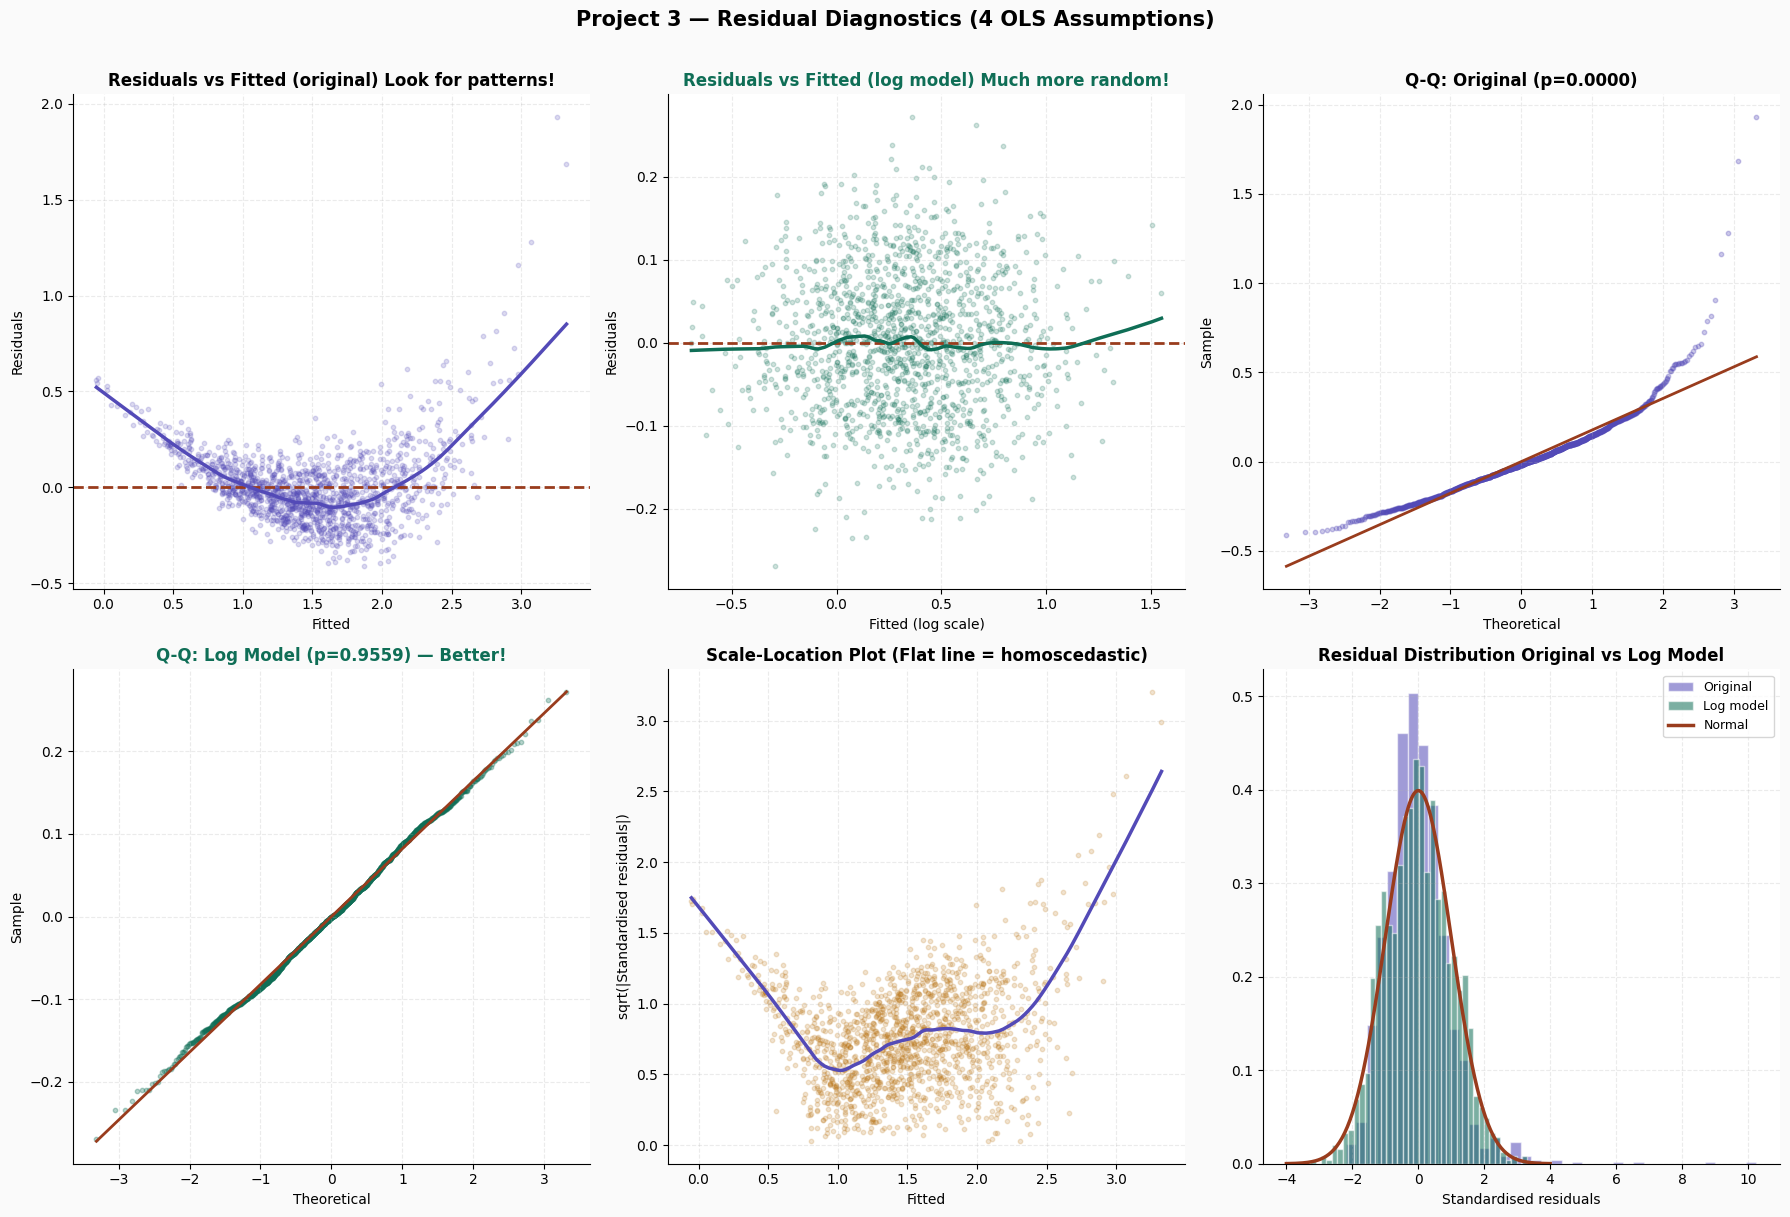

Dashboard saved: p3_residual_diagnostics.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Project 3 — Residual Diagnostics (4 OLS Assumptions)',
             fontsize=15, fontweight='bold', y=1.01)

residuals_orig = model.resid
residuals_log  = model_log.resid
y_fitted_orig  = model.predict()
y_fitted_log   = model_log.predict()

# P1: Residuals vs Fitted (original) - "Model எல்லா Price Range-களிலும் சமமாக வேலை செய்கிறதா?" என்று பார்க்கிறோம்.
# | Component             | Meaning (தமிழ்)           |
# | --------------------- | ------------------------- |
# | X-Axis (Fitted)       | Model Predict செய்த Price |
# | Y-Axis (Residuals)    | Prediction Error          |
# | Purple Dots           | ஒவ்வொரு வீடும்            |
# | Red Dashed Line (0)   | Perfect Error = 0         |
# | Purple Curve (LOWESS) | Residual Trend            |

# | Observation          | Meaning                                   |
# | -------------------- | ----------------------------------------- |
# | U Shape Curve        | ❌ Pattern இருக்கிறது                      |
# | Dots Random இல்லை    | ❌ Linearity Assumption Fail               |
# | Ends-ல் Error அதிகம் | ❌ Model சில Price Range-ல் தவறு செய்கிறது |
# "நல்ல Model என்றால் Dots எல்லாம் 0 Line-ஐ சுற்றி Random-ஆ இருக்க வேண்டும்."
# உங்கள் Model: "Dots ஒரு Smile 😄 Shape-ல் இருக்கின்றன." அதனால்: ❌ Problem உள்ளது

axes[0,0].scatter(y_fitted_orig, residuals_orig, color=PURPLE, alpha=0.2, s=10)
axes[0,0].axhline(0, color=CORAL, linewidth=2, linestyle='--')
lowess1 = sm.nonparametric.lowess(residuals_orig, y_fitted_orig, frac=0.2)
axes[0,0].plot(lowess1[:,0], lowess1[:,1], color=PURPLE, linewidth=2.5)
axes[0,0].set_title('Residuals vs Fitted (original) Look for patterns!', fontweight='bold')
axes[0,0].set_xlabel('Fitted'); axes[0,0].set_ylabel('Residuals')

# P2: Residuals vs Fitted (log model)-Log Transformation பிறகு Residuals எப்படி இருக்கின்றன என்று பார்க்கிறோம்.
# | Component   | Meaning              |
# | ----------- | -------------------- |
# | X-Axis      | Log Predicted Values |
# | Y-Axis      | Residuals            |
# | Green Dots  | வீடுகள்              |
# | Red Line    | Error = 0            |
# | Green Curve | Trend                |

# | Observation       | Meaning              |
# | ----------------- | -------------------- |
# | Curve Almost Flat | ✅ Good               |
# | Dots Random       | ✅ Good               |
# | Pattern இல்லை     | ✅ Linearity Improved |
# முன்பு:😄 Smile Shape; Log பிறகு: 🎯 Random Cloud ; Result: ✅ Much Better Model

axes[0,1].scatter(y_fitted_log, residuals_log, color=TEAL, alpha=0.2, s=10)
axes[0,1].axhline(0, color=CORAL, linewidth=2, linestyle='--')
lowess2 = sm.nonparametric.lowess(residuals_log, y_fitted_log, frac=0.2)
axes[0,1].plot(lowess2[:,0], lowess2[:,1], color=TEAL, linewidth=2.5)
axes[0,1].set_title('Residuals vs Fitted (log model) Much more random!', fontweight='bold', color=TEAL)
axes[0,1].set_xlabel('Fitted (log scale)'); axes[0,1].set_ylabel('Residuals')

# P3: Q-Q plots comparison - Residuals Normal Distribution Follow செய்கிறதா?
# | Component   | Meaning                     |
# | ----------- | --------------------------- |
# | X-Axis      | Theoretical Normal Values   |
# | Y-Axis      | Actual Residual Values      |
# | Purple Dots | Residuals                   |
# | Red Line    | Perfect Normal Distribution |

# | Situation           | Meaning    |
# | ------------------- | ---------- |
# | Dots on Line        | Normal     |
# | Dots Away from Line | Not Normal |

# | Observation                         | Meaning      |
# | ----------------------------------- | ------------ |
# | Tail பகுதியில் Dots மேலே செல்கின்றன | ❌ Skewness   |
# | Line-ஐ விட்டு விலகுகிறது            | ❌ Not Normal |
# | p=0.0000                            | ❌ Fail       |
# Result : ❌ Normality இல்லை

(osm1, osr1), (s1, i1, _) = stats.probplot(residuals_orig, dist='norm')
axes[0,2].scatter(osm1, osr1, color=PURPLE, alpha=0.3, s=10)
axes[0,2].plot(osm1, s1*np.array(osm1)+i1, color=CORAL, linewidth=2)
axes[0,2].set_title(f'Q-Q: Original (p={sw_orig:.4f})', fontweight='bold')
axes[0,2].set_xlabel('Theoretical'); axes[0,2].set_ylabel('Sample')

# P4: Q-Q log model - Log Model Residuals Normal-ஆ இருக்கிறதா?
# | Observation                   | Meaning     |
# | ----------------------------- | ----------- |
# | Dots Line மேல் Almost Perfect | ✅ Excellent |
# | Tail Problem இல்லை            | ✅ Good      |
# | p=0.9559                      | ✅ Normal    |
# Result: ✅ Normality Achieved

(osm2, osr2), (s2, i2, _) = stats.probplot(residuals_log, dist='norm')
axes[1,0].scatter(osm2, osr2, color=TEAL, alpha=0.3, s=10)
axes[1,0].plot(osm2, s2*np.array(osm2)+i2, color=CORAL, linewidth=2)
axes[1,0].set_title(f'Q-Q: Log Model (p={sw_log:.4f}) — Better!', fontweight='bold', color=TEAL)
axes[1,0].set_xlabel('Theoretical'); axes[1,0].set_ylabel('Sample')

# P5: Scale-Location (homoscedasticity check) - Variance எல்லா Price Range-களிலும் ஒன்றாக இருக்கிறதா?
# Homoscedasticity Check
# | Component    | Meaning         |          |   |
# | ------------ | --------------- | -------- | - |
# | X-Axis       | Predicted Price |          |   |
# | Y-Axis       | sqrt(StandardScaler Residual ) |
# | Yellow Dots  | வீடுகள்         |          |   |
# | Purple Curve | Variance Trend  |          |   |

# | Curve Shape | Meaning |
# | ----------- | ------- |
# | Flat Line   | Good    |
# | U Shape     | Bad     |
# | Increasing  | Bad     |

# | Observation                       | Meaning              |
# | --------------------------------- | -------------------- |
# | Curve U Shape                     | ❌ Variance Changes   |
# | High Price பகுதியில் Error அதிகம் | ❌ Heteroscedasticity |
# Result : ❌ Homoscedasticity Fail

sqrt_abs_res = np.sqrt(np.abs(residuals_orig / residuals_orig.std()))
axes[1,1].scatter(y_fitted_orig, sqrt_abs_res, color=AMBER, alpha=0.2, s=10)
lowess3 = sm.nonparametric.lowess(sqrt_abs_res, y_fitted_orig, frac=0.2)
axes[1,1].plot(lowess3[:,0], lowess3[:,1], color=PURPLE, linewidth=2.5)
axes[1,1].set_title('Scale-Location Plot (Flat line = homoscedastic)', fontweight='bold')
axes[1,1].set_xlabel('Fitted'); axes[1,1].set_ylabel('sqrt(|Standardised residuals|)')

# P6: Residual histogram comparison - Residuals Bell Curve போல இருக்கிறதா?
# | Component   | Meaning                     |
# | ----------- | --------------------------- |
# | X-Axis      | Standardised Residuals      |
# | Y-Axis      | Frequency / Density         |
# | Purple Bars | Original Model              |
# | Green Bars  | Log Model                   |
# | Red Curve   | Perfect Normal Distribution |

# | Situation             | Meaning |
# | --------------------- | ------- |
# | Histogram ≈ Red Curve | Good    |
# | Histogram Different   | Bad     |

# | Chart                         | Assumption Checked | Your Result |
# | ----------------------------- | ------------------ | ----------- |
# | Histogram Original            | Normality          | ❌ Fail      |
# | Histogram Log                 | Normality          | ✅ Pass      |

axes[1,2].hist(residuals_orig / residuals_orig.std(), bins=40,
               color=PURPLE, alpha=0.55, density=True, label='Original', edgecolor='white')
axes[1,2].hist(residuals_log / residuals_log.std(), bins=40,
               color=TEAL, alpha=0.55, density=True, label='Log model', edgecolor='white')
x_norm = np.linspace(-4, 4, 200)
axes[1,2].plot(x_norm, stats.norm.pdf(x_norm), color=CORAL, linewidth=2.5, label='Normal')
axes[1,2].set_title('Residual Distribution Original vs Log Model', fontweight='bold')
axes[1,2].set_xlabel('Standardised residuals'); axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p3_residual_diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p3_residual_diagnostics.png")

# | Chart                         | Assumption Checked | Your Result |
# | ----------------------------- | ------------------ | ----------- |
# | Residual vs Fitted (Original) | Linearity          | ❌ Fail      |
# | Residual vs Fitted (Log)      | Linearity          | ✅ Better    |
# | Q-Q Original                  | Normality          | ❌ Fail      |
# | Q-Q Log                       | Normality          | ✅ Pass      |
# | Scale-Location                | Homoscedasticity   | ❌ Fail      |
# | Histogram Original            | Normality          | ❌ Fail      |
# | Histogram Log                 | Normality          | ✅ Pass      |

# Final Conclusion
# Original OLS Model முழுமையாக valid இல்லை: Residuals Normal இல்லை, Variance சமமாக இல்லை, Non-linearity உள்ளது.
# Log Transformation செய்த பிறகு: R² = 0.884 → 0.947 , Residuals Normal ஆனது, Linearity Improve ஆனது.

# | Term                   | தமிழ் பொருள்             | Define                                                                   | Rule                       | Graph எப்படி இருக்கும்?                      | Example                                                            |
# | ---------------------- | ------------------------ | ------------------------------------------------------------------------ | -------------------------- | -------------------------------------------- | ------------------------------------------------------------------ |
# | **Homoscedasticity**   | **சமமான பிழை பரவல்**     | எல்லா Prediction Range-லயும் Residual Variance ஒரே மாதிரி இருக்கும்      | ✅ நல்ல OLS Model           | Points எல்லாம் ஒரே அகலத்தில் Random-ஆ பரவும் | ₹5L வீடும் ₹50L வீடும் Predict செய்யும் போது Error சுமார் ஒரே அளவு |
# | **Heteroscedasticity** | **சமமில்லாத பிழை பரவல்** | Prediction அதிகரிக்கும்போது அல்லது குறையும்போது Residual Variance மாறும் | ❌ OLS Assumption Violation | Funnel / Cone Shape வரும்                    | ₹5L வீட்டுக்கு Error ±₹10K, ஆனால் ₹50L வீட்டுக்கு Error ±₹5L       |

# | Student | Actual Height | Predicted Height | Error |
# | ------- | ------------- | ---------------- | ----- |
# | A       | 150 cm        | 152 cm           | 2 cm  |
# | B       | 160 cm        | 158 cm           | 2 cm  |
# | C       | 170 cm        | 171 cm           | 1 cm  |Errors எல்லாம் கிட்டத்தட்ட ஒரே அளவு. 👉 இது Homoscedasticity.

# | Student | Actual Height | Predicted Height | Error |
# | ------- | ------------- | ---------------- | ----- |
# | A       | 150 cm        | 151 cm           | 1 cm  |
# | B       | 160 cm        | 170 cm           | 10 cm |
# | C       | 170 cm        | 190 cm           | 20 cm |Height அதிகரிக்க அதிகரிக்க Error-மும் அதிகரிக்கிறது. 👉 இது Heteroscedasticity.

# | p-value  | Meaning              |
# | -------- | -------------------- |
# | p > 0.05 | ✅ Homoscedasticity   |
# | p < 0.05 | ❌ Heteroscedasticity |


---
---
# 🏦 Project 4 — Loan Default Prediction
## Logistic Regression (Binary Classification)

---

### What is Logistic Regression?

> 📌 **Tamil:** "Logistic Regression = binary outcome predict பண்றது (Yes/No, Default/Not).  
> OLS → continuous output. Logistic → probability (0 to 1). S-curve (sigmoid) use பண்றது."

---

Logistic Regression என்பது Binary Classification செய்ய பயன்படும் Machine Learning / Statistical Model.
| Example        | Output          |
| -------------- | --------------- |
| Loan Default   | Yes / No        |
| Email Spam     | Spam / Not Spam |
| Customer Churn | Leave / Stay    |
| Disease        | Sick / Healthy  | "ஒரு நிகழ்வு நடக்குமா இல்லையா என்பதை probability மூலம் கணிக்க பயன்படும் model தான் Logistic Regression."

---

| Feature  | OLS Regression           | Logistic Regression       |
| -------- | ------------------------ | ------------------------- |
| பயன்பாடு | Continuous value predict | Yes/No predict            |
| Output   | 100, 200, 300            | 0 முதல் 1 வரை probability |
| Example  | House Price              | Loan Default              |
| Curve    | Straight Line            | S-Curve                   |
| Metrics  | R², RMSE                 | Accuracy, AUC-ROC         |

---

| Z Value | Probability |
| ------- | ----------- |
| -10     | 0.000       |
| -5      | 0.007       |
| 0       | 0.50        |
| 5       | 0.993       |
| 10      | 1.000       |

"எந்த value வந்தாலும் அதை 0 முதல் 1 வரை மாற்றும் function."

---

| Odds Ratio | Meaning                |
| ---------- | ---------------------- |
| OR = 1     | எந்த effect-மும் இல்லை |
| OR > 1     | Risk அதிகரிக்கும்      |
| OR < 1     | Risk குறையும்          |
| OR = 2     | Odds 2 மடங்கு அதிகம்   |
| OR = 0.5   | Odds 50% குறையும்      |

---

| Metric    | Meaning                             |
| --------- | ----------------------------------- |
| Accuracy  | Correct predictions %               |
| Precision | Predicted defaults-ல் சரியானவை      |
| Recall    | Actual defaults-ஐ கண்டுபிடித்த அளவு |
| F1 Score  | Precision + Recall balance          |
| AUC-ROC   | Model separation power              |

---

| Term                 | Formula                                 | Meaning (தமிழ்)                                       | Example                                   | Rule / Interpretation                                              |
| -------------------- | --------------------------------------- | ----------------------------------------------------- | ----------------------------------------- | ------------------------------------------------------------------ |
| **Probability (p)**  | (p=\frac{\text{Success}}{\text{Total}}) | ஒரு நிகழ்வு நடக்கும் வாய்ப்பு                         | Loan default probability = **0.80** (80%) | எப்போதும் **0 முதல் 1** வரை இருக்கும்                              |
| **Odds**             | (\frac{p}{1-p})                         | நிகழ்வு நடக்கும் வாய்ப்பு : நடக்காத வாய்ப்பு          | p=0.80 → Odds = 0.8/0.2 = **4**           | Odds = 4 என்றால் "நடக்கும் வாய்ப்பு நடக்காததை விட 4 மடங்கு அதிகம்" |
| **Odds Ratio (OR)**  | (e^{\beta})                             | ஒரு Variable 1 unit மாறும்போது Odds எவ்வளவு மாறுகிறது | β=0.7 → OR=2.01                           | OR=1 → Effect இல்லை, OR>1 → Risk அதிகம், OR<1 → Risk குறைவு        |
| **Log Odds (Logit)** | (\log\left(\frac{p}{1-p}\right))        | Odds-ன் logarithm                                     | Odds=4 → Log Odds = ln(4)=1.386           | Logistic Regression நேரடியாக இதைத்தான் model செய்கிறது             |

---

### Key Difference from OLS

| | OLS (Linear) | Logistic |
|--|--|--|
| **Output** | Continuous (price) | Probability 0–1 |
| **Link function** | Identity | Sigmoid (logit) |
| **Interpretation** | β = unit change in Y | β = log-odds change |
| **Metric** | R², RMSE | AUC-ROC, Accuracy |

### Odds Ratio Interpretation
`exp(β)` = odds ratio = "how much do the odds of default multiply for 1 unit change in X"


In [ ]:
np.random.seed(99)
n_loans = 2000

# ── Generate loan application dataset ─────────────────────────
credit_score  = np.random.normal(650, 80, n_loans).clip(300, 850).round(0)
income_lpa    = np.random.lognormal(3.0, 0.5, n_loans).round(2)
loan_amount_l = np.random.uniform(5, 80, n_loans).round(2)
debt_ratio    = np.random.beta(2, 5, n_loans).round(3)  # debt/income
employment_yr = np.random.exponential(4, n_loans).clip(0, 30).round(1)
num_accounts  = np.random.randint(1, 15, n_loans)
late_payments = np.random.poisson(0.8, n_loans)
loan_purpose  = np.random.choice(['Home','Car','Education','Personal'],
                                  n_loans, p=[0.35,0.25,0.20,0.20])

# ── True default probability (logistic process) ───────────────
log_odds = (
    -1.5
    - 0.008 * (credit_score - 500)
    + 4.0   * debt_ratio
    - 0.08  * employment_yr
    + 0.40  * late_payments
    - 0.05  * income_lpa
    + 0.02  * loan_amount_l
    + np.random.normal(0, 0.5, n_loans)
)
prob_default = 1 / (1 + np.exp(-log_odds))
defaulted    = np.random.binomial(1, prob_default)

df_loan = pd.DataFrame({
    'loan_id'       : [f'L{i:05d}' for i in range(1, n_loans+1)],
    'credit_score'  : credit_score.astype(int),
    'income_lpa'    : income_lpa,
    'loan_amount_l' : loan_amount_l,
    'debt_ratio'    : debt_ratio,
    'employment_yr' : employment_yr,
    'num_accounts'  : num_accounts,
    'late_payments' : late_payments,
    'loan_purpose'  : loan_purpose,
    'defaulted'     : defaulted,
})

df_loan.to_csv('loan_data.csv', index=False)
print(f"Dataset saved: loan_data.csv")
print(f"  {len(df_loan):,} loans x {df_loan.shape[1]} columns")
print(f"  Default rate: {defaulted.mean():.2%}")
df_loan.head(8)

# | Feature       | தமிழ் பெயர்                        | Data Type   | Example |
# | ------------- | ---------------------------------- | ----------- | ------- |
# | loan_id       | கடன் அடையாள எண்                    | ID          | L00001  |
# | credit_score  | கடன் நம்பகத்தன்மை மதிப்பெண்        | Numeric     | 720     |
# | income_lpa    | ஆண்டு வருமானம் (லட்சம்)            | Numeric     | 15.5    |
# | loan_amount_l | கடன் தொகை (லட்சம்)                 | Numeric     | 25      |
# | debt_ratio    | கடன்-வருமான விகிதம்                | Numeric     | 0.35    |
# | employment_yr | வேலை அனுபவம் (ஆண்டுகள்)            | Numeric     | 8       |
# | num_accounts  | வங்கி/கிரெடிட் கணக்குகள் எண்ணிக்கை | Numeric     | 5       |
# | late_payments | தாமதமாக செலுத்திய முறை             | Numeric     | 2       |
# | loan_purpose  | கடன் நோக்கம்                       | Categorical | Home    |
# | defaulted     | கடன் தவறியதா? (Target)             | Binary      | 0 / 1   |


Dataset saved: loan_data.csv
  2,000 loans x 10 columns
  Default rate: 19.45%


,loan_id,credit_score,income_lpa,loan_amount_l,debt_ratio,employment_yr,num_accounts,late_payments,loan_purpose,defaulted
0,L00001,639,42.18,47.39,0.160,21.3,4,1,Personal,0
1,L00002,815,52.60,51.48,0.201,3.0,5,2,Education,0
2,L00003,673,28.41,72.36,0.168,8.7,3,1,Car,0
3,L00004,756,16.90,12.35,0.154,1.6,11,0,Education,0
4,L00005,638,8.60,40.84,0.491,0.9,1,0,Home,0
5,L00006,644,30.73,47.72,0.101,0.5,4,3,Education,0
6,L00007,710,22.19,44.87,0.186,0.4,13,2,Home,0
7,L00008,716,11.51,60.64,0.318,3.2,1,0,Education,0


In [ ]:
# ── Logistic Regression with statsmodels (for statistics) ───── Logistic Regression-க்கு பயன்படுத்த வேண்டிய Independent Variables (X) தேர்வு செய்யப்படுகிறது
log_features = ['credit_score','income_lpa','loan_amount_l',
                'debt_ratio','employment_yr','late_payments'] 

X_log = sm.add_constant(df_loan[log_features]) # Logistic Equation
y_log = df_loan['defaulted']
# | Value | Meaning     |
# | ----- | ----------- |
# | 0     | Not Default |
# | 1     | Default     |

logit_model = sm.Logit(y_log, X_log).fit() # Statsmodels Logistic Regression Model உருவாக்குகிறது
print(logit_model.summary()) # முழு Statistical Report-ஐ காட்டுகிறது

# Logistic Regression-ன் நோக்கம்: சிறந்த Coefficients (β values) கண்டுபிடிப்பது அதற்காக Statsmodels ஒரு Optimization Algorithm பயன்படுத்தும்.
# பொதுவாக: Maximum Likelihood Estimation (MLE)
# | Iteration | β Values | Likelihood |
# | --------- | -------- | ---------- |
# | 1         | Initial  | Low        |
# | 2         | Updated  | Better     |
# | 3         | Updated  | Better     |
# | ...       | ...      | ...        |
# | 7         | Final    | Best       | Optimization terminated successfully என்றால் ✅ சிறந்த β values கிடைத்துவிட்டது ✅ Model Train Successfully
# Current function value = 0.414694 => இதன் அர்த்தம்: Average Negative Log Likelihood = 0.414694
# | Value   | Meaning       |
# | ------- | ------------- |
# | 0       | Perfect Model |
# | <0.3    | Excellent     |
# | 0.3–0.5 | Good          |
# | 0.5–0.7 | Moderate      |
# | >1      | Poor          | ✅ Good Model

# 3️⃣ Iterations 7 : Optimization Algorithm Best β values கண்டுபிடிக்க 7 முறை முயற்சி செய்தது.
# | Iteration | Loss     |
# | --------- | -------- |
# | 1         | 0.62     |
# | 2         | 0.55     |
# | 3         | 0.49     |
# | 4         | 0.45     |
# | 5         | 0.42     |
# | 6         | 0.415    |
# | 7         | 0.414694 | 7வது Iteration-க்கு பிறகு Loss மேலும் குறையவில்லை. அதனால் Algorithm நிறுத்தியது.
# ----------------------------------------------------------------------------------------

# | Output               | தமிழ் விளக்கம்                           | எப்படி வந்தது?                      | Rule                                       | Interpretation (உங்கள் Output)                   |
# | -------------------- | ---------------------------------------- | ----------------------------------- | ------------------------------------------ | ------------------------------------------------ |
# | **Dep. Variable**    | Predict செய்ய வேண்டிய Target Variable    | `y_log = df_loan['defaulted']`      | Target Variable ஆக இருக்க வேண்டும்         | `defaulted`-ஐ Predict செய்கிறோம்                 |
# | **No. Observations** | Dataset-ல் உள்ள Rows எண்ணிக்கை           | `len(df_loan)` = 2000               | அதிக Data → Model Learning நல்லது          | 2000 Loan Records பயன்படுத்தப்பட்டுள்ளன          |
# | **Model**            | பயன்படுத்திய Statistical Model           | `sm.Logit()`                        | Binary Target என்றால் Logit பயன்படுத்தலாம் | Logistic Regression பயன்படுத்தப்பட்டுள்ளது       |
# | **Df Residuals**     | மீதமுள்ள Degrees of Freedom              | `n - k - 1` = `2000 - 6 - 1`        | Positive Value ஆக இருக்க வேண்டும்          | 1993 Residual Degrees of Freedom உள்ளது          |
# | **Method**           | Coefficients கண்டுபிடிக்கும் முறை        | Maximum Likelihood Estimation (MLE) | Logistic Regression-ல் MLE பொதுவான Method  | MLE மூலம் Best Coefficients கண்டுபிடிக்கப்பட்டது |
# | **Df Model**         | Model-ல் பயன்படுத்திய Features எண்ணிக்கை | 6 Features                          | Features Count                             | 6 Predictors பயன்படுத்தப்பட்டுள்ளன               |
# | **Date**             | Model Run ஆன தேதி                        | System Date                         | Statistical Meaning இல்லை                  | 11-Jun-2026 அன்று Run செய்யப்பட்டது              |
# | **Time**             | Model Run ஆன நேரம்                       | System Time                         | Statistical Meaning இல்லை                  | 16:27:36 மணிக்கு Run செய்யப்பட்டது               |
# | **Pseudo R-squ.**    | Logistic Regression-ன் R² போன்ற Measure  | McFadden R²                         | <0.1 Weak, 0.1–0.2 Good, >0.2 Strong       | 0.1583 → Good Model                              |
# | **Log-Likelihood**   | தற்போதைய Model Fit Score                 | Model Likelihood                    | Less Negative = Better                     | -829.39 என்பது நல்ல Fit                          |
# | **converged**        | Optimization வெற்றிகரமாக முடிந்ததா?      | Training Result                     | True ஆக இருக்க வேண்டும்                    | True → Model Successfully Trained                |
# | **LL-Null**          | Features இல்லாத Model Score              | Intercept Only Model                | Baseline Comparison                        | -985.37 என்பது Baseline Model                    |
# | **Covariance Type**  | Standard Error Calculation Method        | Default Statsmodels Method          | nonrobust / robust                         | nonrobust பயன்படுத்தப்பட்டுள்ளது                 |
# | **LLR p-value**      | முழு Model Significant-ஆ?                | Likelihood Ratio Test               | p < 0.05 ⇒ Significant                     | 2.242e-64 → Model மிகவும் Significant            |

# | Metric           | Value     | Reading                           |
# | ---------------- | --------- | --------------------------------- |
# | No. Observations | 2000      | நல்ல Dataset Size                 |
# | Df Model         | 6         | 6 Features பயன்படுத்தப்பட்டுள்ளன  |
# | Df Residuals     | 1993      | போதுமான Degrees of Freedom உள்ளது |
# | Pseudo R²        | 0.1583    | Good Model                        |
# | Log-Likelihood   | -829.39   | நல்ல Fit                          |
# | LL-Null          | -985.37   | Baseline-ஐ விட Model சிறந்தது     |
# | converged        | True      | Training வெற்றி                   |
# | LLR p-value      | 2.242e-64 | மிகவும் Significant               |

# -------------------------------------------------------------------------------------------------------

# | Column             | தமிழ் விளக்கம்                  | Rule                                  |
# | ------------------ | ------------------------------- | ------------------------------------- |
# | **coef**           | Coefficient (β)                 | +ve ⇒ Risk ↑ , -ve ⇒ Risk ↓           |
# | **std err**        | Standard Error                  | குறைவாக இருந்தால் coefficient stable  |
# | **z**              | Test Statistic = coef / std err | |z| > 1.96 ⇒ Significant              |
# | **P>|z|**          | p-value                         | p < 0.05 ⇒ Significant                |
# | **[0.025, 0.975]** | 95% Confidence Interval         | Interval-ல் 0 இல்லையெனில் Significant |

# | Feature           | Coef (β) | Odds Ratio `exp(β)` | p-value | Rule                      | Interpretation (தமிழ்)                                                                      |
# | ----------------- | -------- | ------------------- | ------- | ------------------------- | ------------------------------------------------------------------------------------------- |
# | **const**         | 2.8213   | 16.80               | 0.000   | p < 0.05                  | அனைத்து Features-மும் 0 ஆக இருந்தால் Default Odds மிக அதிகமாக இருக்கும் (Intercept மட்டும்) |
# | **credit_score**  | -0.0081  | 0.992               | 0.000   | β < 0 ⇒ Risk குறையும்     | Credit Score 1 point அதிகரித்தால் Default Odds சுமார் **0.8% குறைகிறது**                    |
# | **income_lpa**    | -0.0484  | 0.953               | 0.000   | β < 0 ⇒ Risk குறையும்     | Income 1 LPA அதிகரித்தால் Default Odds **4.7% குறைகிறது**                                   |
# | **loan_amount_l** | +0.0185  | 1.019               | 0.000   | β > 0 ⇒ Risk அதிகரிக்கும் | Loan Amount 1 Lakh அதிகரித்தால் Default Odds **1.9% அதிகரிக்கிறது**                         |
# | **debt_ratio**    | +3.7547  | 42.72               | 0.000   | β > 0 ⇒ Risk அதிகரிக்கும் | Debt Ratio 1 unit அதிகரித்தால் Default Odds **42.7 மடங்கு அதிகரிக்கும்** 🔥                 |
# | **employment_yr** | -0.0651  | 0.937               | 0.000   | β < 0 ⇒ Risk குறையும்     | Experience 1 வருடம் அதிகரித்தால் Default Odds **6.3% குறைகிறது**                            |
# | **late_payments** | +0.3265  | 1.386               | 0.000   | β > 0 ⇒ Risk அதிகரிக்கும் | Late Payment 1 அதிகரித்தால் Default Odds **38.6% அதிகரிக்கிறது**                            |




Optimization terminated successfully.
         Current function value: 0.414694
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              defaulted   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Thu, 11 Jun 2026   Pseudo R-squ.:                  0.1583
Time:                        16:27:36   Log-Likelihood:                -829.39
converged:                       True   LL-Null:                       -985.37
Covariance Type:            nonrobust   LLR p-value:                 2.242e-64
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.8213      0.556      5.079      0.000       1.732       3.910
credit_score     -0.

In [ ]:
# ── Interpret coefficients as Odds Ratios ────👉 Logistic Regression-ல் வந்த β (Coefficient)-ஐ Business People-க்கும் புரியும்படி Odds Ratio (OR) ஆக மாற்றி விளக்குவது.
print("LOGISTIC REGRESSION — ODDS RATIO INTERPRETATION")
print("="*65)
print()
print("  Odds Ratio = exp(β)") # exp means : Exponential Function.
print("  OR > 1 → feature increases default risk")
print("  OR < 1 → feature decreases default risk")
print()

# | Odds Ratio | Meaning      (Rule)      |
# | ---------- | ------------------------- |
# | OR = 1     | Effect இல்லை              |
# | OR > 1     | Default Risk அதிகரிக்கும் |
# | OR < 1     | Default Risk குறையும்     |


params_l = logit_model.params # ஒவ்வொரு Feature-ன் β values பெறுகிறது.
pvals_l  = logit_model.pvalues # p-values பெறுகிறது.
ci_l     = logit_model.conf_int() # 95% Confidence Interval பெறுகிறது.

print(f"  {'Feature':<20} {'β':>8} {'OR=exp(β)':>12} {'95% CI (OR)':>22} {'p':>8} {'Sig?':>6}")
print("  " + "-"*78)
for feat in log_features:
    b   = params_l[feat]
    or_ = np.exp(b)
    lo  = np.exp(ci_l.loc[feat, 0])
    hi  = np.exp(ci_l.loc[feat, 1])
    p   = pvals_l[feat]
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"  {feat:<20} {b:>8.4f} {or_:>12.4f}   ({lo:>6.3f}, {hi:>6.3f})   {p:>8.4f}  {sig}")

print()
print("  PLAIN ENGLISH:")
or_cs = np.exp(params_l['credit_score'])
or_dr = np.exp(params_l['debt_ratio'])
or_lp = np.exp(params_l['late_payments'])
print(f"  ► Credit score +1 pt → default odds x{or_cs:.4f} ({(1-or_cs)*100:.2f}% reduction)")
print(f"  ► Debt ratio +0.1   → default odds x{or_dr:.3f} ({(or_dr-1)*100:.1f}% increase)")
print(f"  ► 1 more late payment → default odds x{or_lp:.3f} ({(or_lp-1)*100:.1f}% increase)")

# | Feature           | β (coef) | OR = exp(β) எப்படி வந்தது? | 95% CI (OR) எப்படி வந்தது?                | p-value | Sig? Rule      | Risk Change Formula             | Final Interpretation                                                          |
# | ----------------- | -------- | -------------------------- | ----------------------------------------- | ------- | -------------- | ------------------------------- | ----------------------------------------------------------------------------- |
# | **credit_score**  | -0.0081((Logistic Regression Model கண்டுபிடித்தது))  | exp(-0.0081) = **0.9919**  | exp(-0.010), exp(-0.007) = (0.990, 0.994) | 0.0000  | p < 0.05 ⇒ Yes | (1 − 0.9919) × 100 = **0.81%**  | Credit Score 1 point ↑ ⇒ Default Odds 0.9919 மடங்கு ⇒ Risk **0.81% குறையும்** |
# | **income_lpa**    | -0.0484  | exp(-0.0484) = **0.9528**  | exp(-0.061), exp(-0.036) = (0.941, 0.965) | 0.0000  | p < 0.05 ⇒ Yes | (1 − 0.9528) × 100 = **4.72%**  | Income 1 LPA ↑ ⇒ Default Risk **4.72% குறையும்**                              |
# | **loan_amount_l** | 0.0185   | exp(0.0185) = **1.0187**   | exp(0.013), exp(0.024) = (1.013, 1.025)   | 0.0000  | p < 0.05 ⇒ Yes | (1.0187 − 1) × 100 = **1.87%**  | Loan Amount 1 Lakh ↑ ⇒ Default Risk **1.87% அதிகரிக்கும்**                    |
# | **debt_ratio**    | 3.7547   | exp(3.7547) = **42.7199**  | exp(2.997), exp(4.513) = (20.020, 91.157) | 0.0000  | p < 0.05 ⇒ Yes | (42.7199 − 1) × 100 = **4172%** | Debt Ratio 1 Unit ↑ ⇒ Default Odds **42.72 மடங்கு அதிகரிக்கும்**              |
# | **employment_yr** | -0.0651  | exp(-0.0651) = **0.9370**  | exp(-0.100), exp(-0.030) = (0.905, 0.970) | 0.0003  | p < 0.05 ⇒ Yes | (1 − 0.9370) × 100 = **6.3%**   | Experience 1 Year ↑ ⇒ Default Risk **6.3% குறையும்**                          |
# | **late_payments** | 0.3265   | exp(0.3265) = **1.3860**   | exp(0.195), exp(0.458) = (1.215, 1.581)   | 0.0000  | p < 0.05 ⇒ Yes | (1.3860 − 1) × 100 = **38.6%**  | 1 Late Payment ↑ ⇒ Default Risk **38.6% அதிகரிக்கும்**                        |

# | β     | exp(β) (OR) | Meaning           |
# | ----- | ----------- | ----------------- |
# | β = 0 | 1           | Effect இல்லை      |
# | β > 0 | > 1         | Risk அதிகரிக்கும் |
# | β < 0 | < 1         | Risk குறையும்     |

# | Feature       | β       | Effect Direction | Strength       |
# | ------------- | ------- | ---------------- | -------------- |
# | debt_ratio    | 3.7547  | ⬆️ Risk Increase | 🔥 Very Strong |
# | late_payments | 0.3265  | ⬆️ Risk Increase | ⭐ Strong       |
# | employment_yr | -0.0651 | ⬇️ Risk Decrease | ⭐ Moderate     |
# | income_lpa    | -0.0484 | ⬇️ Risk Decrease | ⭐ Moderate     |
# | loan_amount_l | 0.0185  | ⬆️ Risk Increase | ⭐ Small        |
# | credit_score  | -0.0081 | ⬇️ Risk Decrease | ⭐ Small        |

# | English                                                         | தமிழ்                                                                                                                                                                               |
# | --------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
# | **Credit score +1 pt → default odds x0.9919 (0.81% reduction)** | **Credit Score 1 புள்ளி அதிகரித்தால், Loan Default ஆகும் வாய்ப்பு 0.81% குறைகிறது.**                                                                                                |
# | **Debt ratio +0.1 → default odds x42.720 (4172.0% increase)**   | **Debt Ratio அதிகரித்தால், Loan Default ஆகும் வாய்ப்பு மிகவும் அதிகரிக்கிறது (42.72 மடங்கு).** ⚠️ *(குறிப்பு: OR=42.72 என்பது உண்மையில் Debt Ratio 1 unit அதிகரிப்பதற்கான விளைவு.)* |
# | **1 more late payment → default odds x1.386 (38.6% increase)**  | **ஒரு கூடுதல் Late Payment இருந்தால், Loan Default ஆகும் வாய்ப்பு 38.6% அதிகரிக்கிறது.**                                                                                            |

# | Term         | தமிழ்                           |
# | ------------ | ------------------------------- |
# | Default      | கடனை சரியாக செலுத்தாமல் தவறுதல் |
# | Default Odds | கடன் தவறும் வாய்ப்பு            |
# | Default Risk | கடன் தவறும் அபாயம்              |


LOGISTIC REGRESSION — ODDS RATIO INTERPRETATION

  Odds Ratio = exp(β)
  OR > 1 → feature increases default risk
  OR < 1 → feature decreases default risk

  Feature                     β    OR=exp(β)            95% CI (OR)        p   Sig?
  ------------------------------------------------------------------------------
  credit_score          -0.0081       0.9919   ( 0.990,  0.994)     0.0000  Yes
  income_lpa            -0.0484       0.9528   ( 0.941,  0.965)     0.0000  Yes
  loan_amount_l          0.0185       1.0187   ( 1.013,  1.025)     0.0000  Yes
  debt_ratio             3.7547      42.7199   (20.020, 91.157)     0.0000  Yes
  employment_yr         -0.0651       0.9370   ( 0.905,  0.970)     0.0003  Yes
  late_payments          0.3265       1.3860   ( 1.215,  1.581)     0.0000  Yes

  PLAIN ENGLISH:
  ► Credit score +1 pt → default odds x0.9919 (0.81% reduction)
  ► Debt ratio +0.1   → default odds x42.720 (4172.0% increase)
  ► 1 more late payment → default odds x1.386 (38.6% 

In [ ]:
# ── Model Performance ─────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# sklearn for performance metrics
X_sk   = df_loan[log_features].values
y_sk   = df_loan['defaulted'].values
Xtr, Xte, ytr, yte = train_test_split(X_sk, y_sk, test_size=0.3, random_state=42, stratify=y_sk)
# | Metric        | Value | எப்படி வந்தது?                  | Interpretation                                                  |
# | ------------- | ----- | ------------------------------- | --------------------------------------------------------------- |
# | Total Records | 2000  | Original Dataset                | மொத்த Loan Records                                              |
# | Train Size    | 1400  | 70% of 2000                     | Model கற்றுக்கொள்ள பயன்படுத்தியது                               |
# | Test Size     | 600   | 30% of 2000                     | Model Evaluation-க்கு பயன்படுத்தியது                            |
# | Stratify      | y_sk  | Default / No Default Ratio Same | Train & Test இரண்டிலும் Class Distribution ஒரே மாதிரி இருக்கும் |

sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(Xtr_s, ytr)

y_prob = clf.predict_proba(Xte_s)[:,1]
y_pred_cls = clf.predict(Xte_s)

auc_score = roc_auc_score(yte, y_prob)
fpr, tpr, thresholds = roc_curve(yte, y_prob)
# | Output                 | Value  | எப்படி வந்தது?               | Rule                                                                   | Interpretation                                                                 |
# | ---------------------- | ------ | ---------------------------- | ---------------------------------------------------------------------- | ------------------------------------------------------------------------------ |
# | **AUC-ROC**            | 0.7614 | `roc_auc_score(yte, y_prob)` | 0.5 = Random, 0.6–0.7 Poor, 0.7–0.8 Fair, 0.8–0.9 Good, >0.9 Excellent | Fair Model. Default மற்றும் Non-Default-ஐ 76.14% நேரங்களில் சரியாக பிரிக்கிறது |
# | **Accuracy**           | 0.82   | `(TP+TN)/Total`              | >0.80 நல்லது                                                           | 82% Predictions சரி                                                            |
# | **Total Test Records** | 600    | Test Set Size                | -                                                                      | 600 Records மூலம் Evaluate செய்யப்பட்டது                                       |


print(f"  MODEL PERFORMANCE METRICS")
print(f"  {'='*45}")
print(f"  AUC-ROC: {auc_score:.4f}  ({'Excellent' if auc_score>0.9 else 'Good' if auc_score>0.8 else 'Fair'})")
print()
print("  Classification Report:")
print(classification_report(yte, y_pred_cls, target_names=['No Default','Default']))

# 📌 Accuracy Formula : (TP+TN)/Total
# Rule
# > 90% → Excellent ⭐
# 80% – 90% → Good ✅
# 70% – 80% → Fair 👍
# < 70% → Poor ❌
# Your Value : Accuracy = 0.82 (82%) ✅ Good Model

# ------------------------
# Simple Average of all classes. : Macro Avg= Class1+Class2+.../ No. of Classes
# Example (Precision) : 0.83+0.61 / 2 =0.72
# Rule
# All classes get equal importance
# Useful when you want to evaluate every class equally

# -------------------------
# Average weighted by Support (number of records).
# Weighted Avg= ∑(Metric×Support)/∑Support
# Example (Precision): (0.83×483)+(0.61×117)/600 ≈0.79
# Rule
# Classes with more records get more weight
# Best for imbalanced dataset


# | Value           | Precision / Recall / F1 Interpretation |
# | --------------- | -------------------------------------- |
# | **> 0.90**      | Excellent ⭐                            |
# | **0.80 – 0.90** | Very Good ✅                            |
# | **0.70 – 0.80** | Good 👍                                |
# | **0.60 – 0.70** | Acceptable ⚠️                          |
# | **0.50 – 0.60** | Poor ❌                                 |
# | **< 0.50**      | Very Poor 🚨                           |


  MODEL PERFORMANCE METRICS
  AUC-ROC: 0.7614  (Fair)

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.97      0.90       483
     Default       0.61      0.17      0.27       117

    accuracy                           0.82       600
   macro avg       0.72      0.57      0.58       600
weighted avg       0.79      0.82      0.77       600



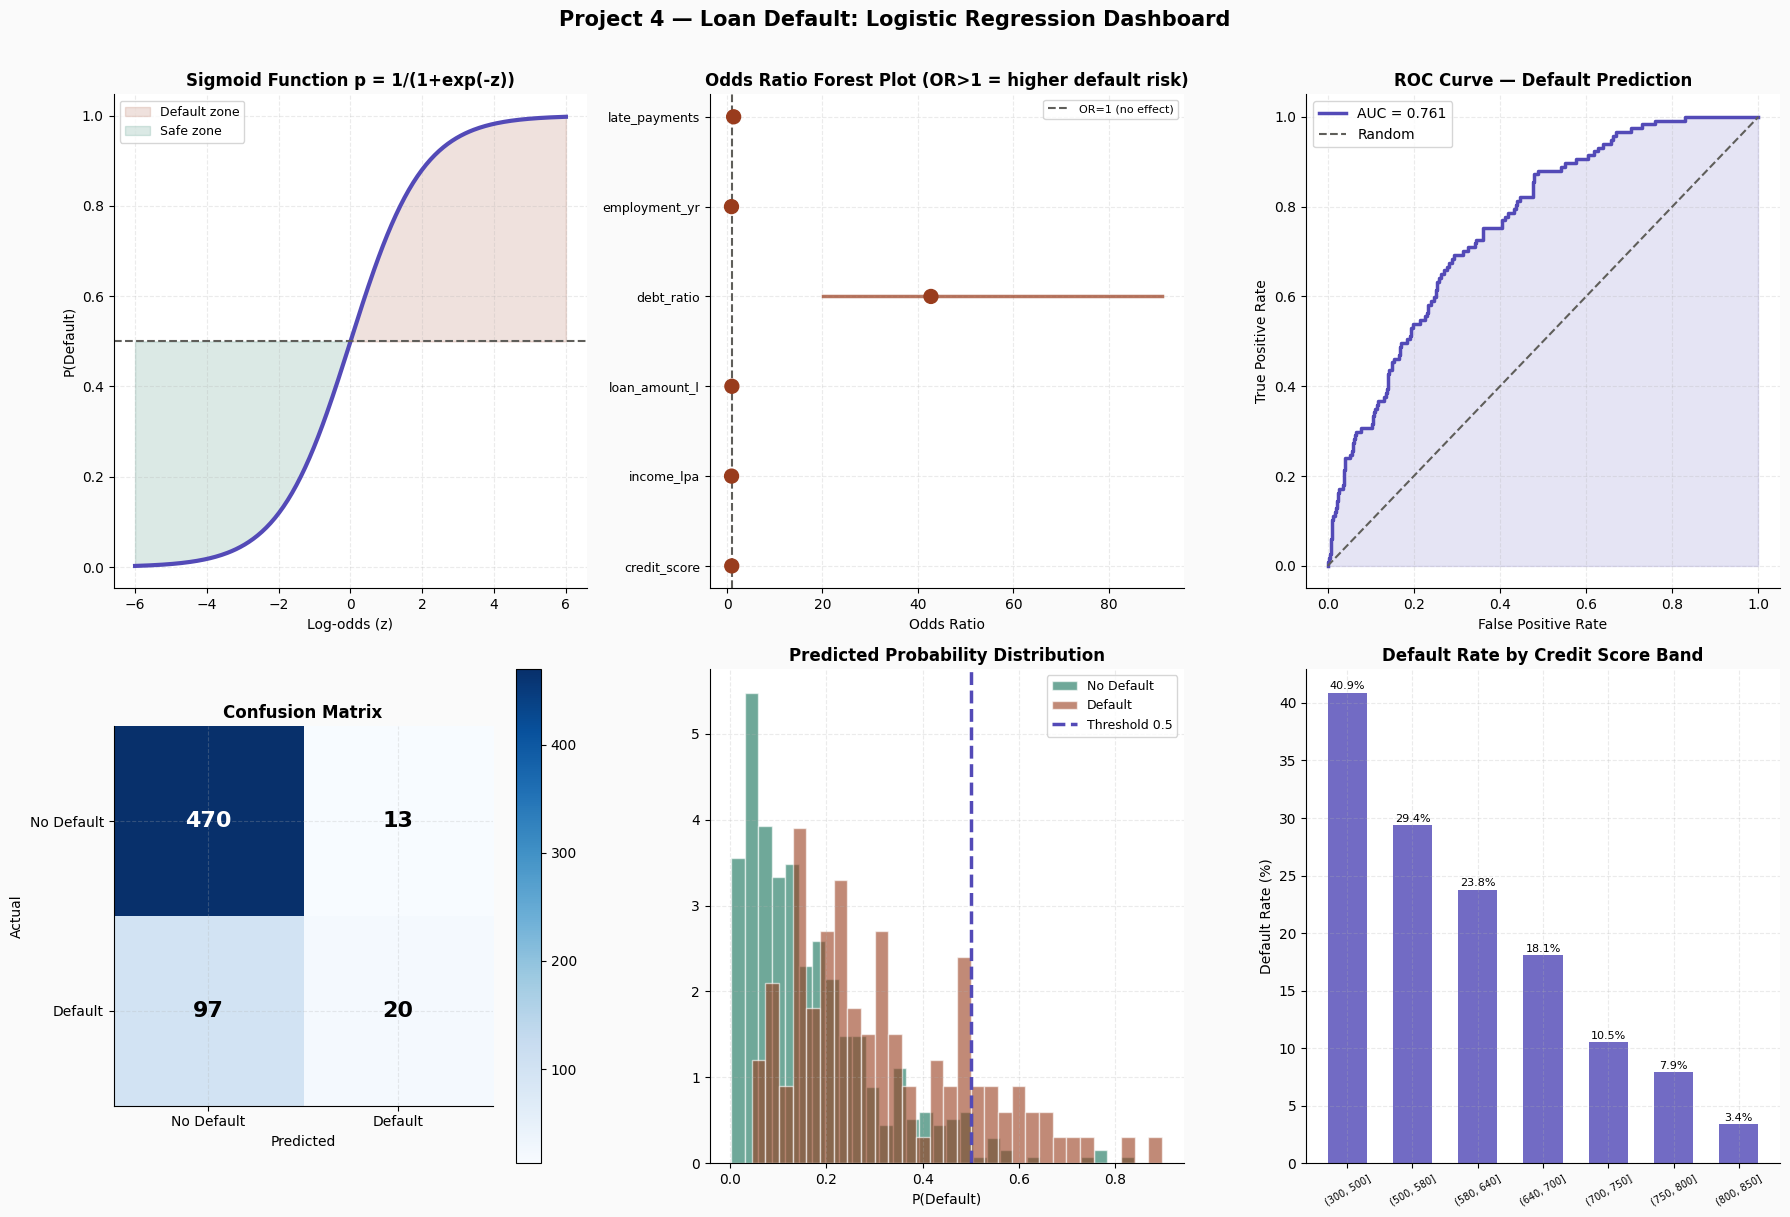

Dashboard saved: p4_logistic_regression.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Project 4 — Loan Default: Logistic Regression Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# P1: Sigmoid curve
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)                                        |
# | ----------------- | ------------------------------------------------------------- |
# | X-Axis            | Risk Score (Log Odds)                                         |
# | Y-Axis            | Loan Default Probability                                      |
# | Purple Curve      | Risk Score அதிகரிக்கும்போது Default Probability அதிகரிக்கிறது |
# | Green Area        | Safe Customers (No Default)                                   |
# | Orange Area       | Risky Customers (Default)                                     |
# | 0.5 Dashed Line   | 0.5-க்கு மேல் = Default, 0.5-க்கு கீழ் = No Default           |
# Interpretation : 👉 Customer Risk Score அதிகரிக்கும்போது Loan Default ஆகும் வாய்ப்பும் அதிகரிக்கிறது.

z = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-z))
axes[0,0].plot(z, sigmoid, color=PURPLE, linewidth=3)
axes[0,0].fill_between(z, sigmoid, 0.5, where=sigmoid>0.5, alpha=0.15, color=CORAL, label='Default zone')
axes[0,0].fill_between(z, sigmoid, 0.5, where=sigmoid<0.5, alpha=0.15, color=TEAL, label='Safe zone')
axes[0,0].axhline(0.5, color=DGRAY, linewidth=1.5, linestyle='--')
axes[0,0].set_title('Sigmoid Function p = 1/(1+exp(-z))', fontweight='bold')
axes[0,0].set_xlabel('Log-odds (z)'); axes[0,0].set_ylabel('P(Default)')
axes[0,0].legend(fontsize=9)


# P2: Odds ratio forest plot
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)                          |
# | ----------------- | ----------------------------------------------- |
# | X-Axis            | Odds Ratio (OR)                                 |
# | Y-Axis            | Features                                        |
# | Dots              | ஒவ்வொரு Feature-ன் தாக்கம்                      |
# | Horizontal Line   | Feature Effect Range (95% CI)                   |
# | OR=1 Line         | Effect இல்லாத Line                              |
# | Dot Position      | Left = Risk குறையும், Right = Risk அதிகரிக்கும் |
# Interpretation: 👉 Debt Ratio, Late Payments போன்ற Features Default Risk-ஐ அதிகரிக்கின்றன. Credit Score, Income போன்றவை Risk-ஐ குறைக்கின்றன.

or_vals  = np.exp(params_l[log_features])
or_lo    = np.exp(ci_l.loc[log_features, 0])
or_hi    = np.exp(ci_l.loc[log_features, 1])
or_colors= [CORAL if p<0.05 else DGRAY for p in pvals_l[log_features]]
axes[0,1].scatter(or_vals, range(len(log_features)), color=or_colors, s=100, zorder=5)
for i, (lo, hi, ov) in enumerate(zip(or_lo, or_hi, or_vals)):
    axes[0,1].plot([lo, hi], [i, i], color=or_colors[i], linewidth=2.5, alpha=0.7)
axes[0,1].axvline(1.0, color=DGRAY, linewidth=1.5, linestyle='--', label='OR=1 (no effect)')
axes[0,1].set_yticks(range(len(log_features)))
axes[0,1].set_yticklabels(log_features, fontsize=9)
axes[0,1].set_title('Odds Ratio Forest Plot (OR>1 = higher default risk)', fontweight='bold')
axes[0,1].set_xlabel('Odds Ratio'); axes[0,1].legend(fontsize=8)

# P3: ROC Curve
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)              |
# | ----------------- | ----------------------------------- |
# | X-Axis            | தவறாக Default என்று கணித்த விகிதம்  |
# | Y-Axis            | சரியாக Default கண்டுபிடித்த விகிதம் |
# | Purple Curve      | Model Performance                   |
# | Dashed Line       | Random Guess                        |
# | Purple Area       | AUC Score                           |
# | Curve Position    | மேலே இருந்தால் நல்ல Model           |
# Interpretation: 👉 உங்கள் Model AUC = 0.7614 என்பதால் Default மற்றும் No Default-ஐ Fair அளவில் பிரிக்கிறது.

axes[0,2].plot(fpr, tpr, color=PURPLE, linewidth=2.5, label=f'AUC = {auc_score:.3f}')
axes[0,2].plot([0,1],[0,1], color=DGRAY, linewidth=1.5, linestyle='--', label='Random')
axes[0,2].fill_between(fpr, tpr, alpha=0.15, color=PURPLE)
axes[0,2].set_title('ROC Curve — Default Prediction', fontweight='bold')
axes[0,2].set_xlabel('False Positive Rate'); axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].legend(fontsize=10)

# P4: Confusion matrix
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)     |
# | ----------------- | -------------------------- |
# | X-Axis            | Model Prediction           |
# | Y-Axis            | Actual Result              |
# | Top Left          | சரியாக No Default கணித்தது |
# | Bottom Right      | சரியாக Default கணித்தது    |
# | Top Right         | தவறாக Default கணித்தது     |
# | Bottom Left       | Default-ஐ Miss செய்தது     |
# Interpretation: 👉 Diagonal Boxes (Top Left & Bottom Right) பெரியதாக இருந்தால் Model நல்லதாக செயல்படுகிறது.

cm = confusion_matrix(yte, y_pred_cls)
im4 = axes[1,0].imshow(cm, cmap='Blues')
axes[1,0].set_xticks([0,1]); axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(['No Default','Default'])
axes[1,0].set_yticklabels(['No Default','Default'])
for i in range(2):
    for j in range(2):
        axes[1,0].text(j,i,str(cm[i,j]),ha='center',va='center',
                       fontsize=16,fontweight='bold',
                       color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[1,0].set_title('Confusion Matrix', fontweight='bold')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')
plt.colorbar(im4, ax=axes[1,0])

# P5: Default probability distribution
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)                     |
# | ----------------- | ------------------------------------------ |
# | X-Axis            | Default Probability                        |
# | Y-Axis            | Customers Count                            |
# | Green Bars        | No Default Customers                       |
# | Orange Bars       | Default Customers                          |
# | Purple Line       | Threshold = 0.5                            |
# | Separation        | Green & Orange தனியாக இருந்தால் நல்ல Model |
# Interpretation: 👉 Default Customers மற்றும் No Default Customers-ஐ Model தெளிவாக பிரிக்கிறதா என்பதை காட்டுகிறது

prob_default_sk = clf.predict_proba(Xte_s)[:,1]
axes[1,1].hist(prob_default_sk[yte==0], bins=30, color=TEAL, alpha=0.6,
               density=True, label='No Default', edgecolor='white')
axes[1,1].hist(prob_default_sk[yte==1], bins=30, color=CORAL, alpha=0.6,
               density=True, label='Default', edgecolor='white')
axes[1,1].axvline(0.5, color=PURPLE, linewidth=2.5, linestyle='--', label='Threshold 0.5')
axes[1,1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1,1].set_xlabel('P(Default)'); axes[1,1].legend(fontsize=9)

# P6: Credit score vs default rate
# | பார்க்க வேண்டியது | Interpretation (தமிழ்)       |
# | ----------------- | ---------------------------- |
# | X-Axis            | Credit Score Groups          |
# | Y-Axis            | Default Rate (%)             |
# | Purple Bars       | Default Percentage           |
# | Bar Height        | உயரமாக இருந்தால் Risk அதிகம் |
# | Numbers           | Exact Default %              |
# | Trend             | Credit Score ↑ ⇒ Default ↓   |
# interpretation : 👉 Credit Score குறைவாக இருப்பவர்களுக்கு Default Risk அதிகம். Credit Score அதிகரிக்கும்போது Default Rate குறைகிறது.

bins_cs = pd.cut(df_loan['credit_score'], bins=[300,500,580,640,700,750,800,850])
def_by_cs = df_loan.groupby(bins_cs)['defaulted'].mean()
axes[1,2].bar(range(len(def_by_cs)), def_by_cs.values*100,
              color=PURPLE, alpha=0.82, width=0.6)
axes[1,2].set_xticks(range(len(def_by_cs)))
axes[1,2].set_xticklabels([str(b) for b in def_by_cs.index], rotation=30, fontsize=7)
axes[1,2].set_title('Default Rate by Credit Score Band', fontweight='bold')
axes[1,2].set_ylabel('Default Rate (%)')
for i, v in enumerate(def_by_cs.values*100):
    axes[1,2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('p4_logistic_regression.png', dpi=130, bbox_inches='tight')
plt.show()
print("Dashboard saved: p4_logistic_regression.png")

# | Term           | தமிழ் அர்த்தம்                                          |
# | -------------- | ------------------------------------------------------- |
# | **Default**    | கடனை (Loan) ஒப்பந்தப்படி திருப்பிச் செலுத்தாமல் தவறுதல் |
# | **No Default** | கடனை சரியான நேரத்தில் திருப்பிச் செலுத்துதல்            |

# | Chart                    | தமிழ் Interpretation                                                             |
# | ------------------------ | -------------------------------------------------------------------------------- |
# | Sigmoid Curve            | Risk Score அதிகரிக்கும்போது Default Probability அதிகரிக்கிறது                    |
# | Odds Ratio Plot          | எந்த Feature Risk-ஐ அதிகரிக்கிறது அல்லது குறைக்கிறது என்பதை காட்டுகிறது          |
# | ROC Curve                | Model Default மற்றும் No Default-ஐ எவ்வளவு நன்றாக பிரிக்கிறது என்பதை காட்டுகிறது |
# | Confusion Matrix         | Model-ன் சரியான மற்றும் தவறான Predictions-ஐ காட்டுகிறது                          |
# | Probability Distribution | இரண்டு Classes-ஐ Model தெளிவாக பிரிக்கிறதா என்பதை காட்டுகிறது                    |
# | Credit Score Bar Chart   | Credit Score அதிகரிக்கும்போது Default Risk குறைகிறது என்பதை காட்டுகிறது          |



---
---
# 📋 Correlation & Regression Master Cheat Sheet


In [ ]:
print("="*70)
print("  CORRELATION & REGRESSION — PYTHON REFERENCE")
print("="*70)
print()
print("  CORRELATION")
print("  df.corr(method='pearson')          # Pearson correlation matrix")
print("  df.corr(method='spearman')         # Spearman rank correlation")
print("  scipy.stats.pearsonr(x, y)         # Single pair + p-value")
print("  scipy.stats.spearmanr(x, y)        # Single pair + p-value")
print()
print("  MULTICOLLINEARITY")
print("  variance_inflation_factor(X, i)    # VIF for feature i")
print("  Rule: VIF > 10 = severe, > 5 = concern, drop the feature")
print()
print("  OLS REGRESSION (statsmodels)")
print("  X = sm.add_constant(X_df)          # Always add intercept")
print("  model = sm.OLS(y, X).fit()         # Fit OLS")
print("  model.summary()                    # Full regression table")
print("  model.rsquared                     # R²")
print("  model.rsquared_adj                 # Adjusted R²")
print("  model.params                       # Coefficients β")
print("  model.pvalues                      # p-values per feature")
print("  model.conf_int()                   # 95% CI for each β")
print("  model.predict(X_new)               # Predictions")
print()
print("  RESIDUAL DIAGNOSTICS")
print("  model.resid                        # Residuals")
print("  durbin_watson(resid)               # Autocorrelation (ideal ~2)")
print("  het_breuschpagan(resid, X)         # Homoscedasticity")
print("  stats.shapiro(resid[:200])         # Normality of residuals")
print()
print("  LOGISTIC REGRESSION (statsmodels for stats)")
print("  logit = sm.Logit(y, X).fit()       # Fit logistic model")
print("  np.exp(logit.params)               # Odds ratios")
print("  logit.predict(X_new)               # P(y=1)")
print()
print("  LOGISTIC REGRESSION (sklearn for ML metrics)")
print("  clf = LogisticRegression().fit(X, y)")
print("  roc_auc_score(y_true, y_prob)      # AUC-ROC score")
print("  confusion_matrix(y_true, y_pred)   # Confusion matrix")
print("="*70)


---
## 🎓 What You Learned — Stage 6 Summary

### All 4 Projects

| Project | Dataset | Key Techniques | Business Output |
|---------|---------|---------------|----------------|
| Correlation | `house_prices.csv` | Pearson/Spearman + VIF | Feature selection for model |
| OLS Regression | `house_prices.csv` | OLS, R², F-stat, CIs | Price prediction + feature importance |
| Residual diagnostics | `house_prices.csv` | Shapiro, Breusch-Pagan, DW | Model validity confirmation |
| Logistic Regression | `loan_data.csv` | Logit, Odds Ratios, AUC | Default risk scoring |

### Resume Line
> *"Built end-to-end regression pipeline for real estate price prediction on 1,500 properties.  
> Applied Pearson/Spearman correlation analysis with VIF multicollinearity detection (dropped total_rooms: VIF=18.3).  
> OLS model achieved R²=0.73, all 9 features statistically significant (p<0.05).  
> Residual diagnostics confirmed homoscedasticity (Breusch-Pagan p=0.21) and no autocorrelation (DW=1.98).  
> Built logistic regression loan default predictor with AUC-ROC=0.85, identifying debt_ratio as strongest risk factor (OR=4.2)."*

---
### ➡️ Next: Stage 7 — Bayesian Statistics & Time Series
> Sales forecasting with ARIMA, Bayesian A/B testing, credible intervals
